In [1]:
from __future__ import annotations

import json
import math
import warnings
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.stats import kendalltau
from IPython.display import display


def find_project_root(start: Path | None = None) -> Path:
    if start is None:
        start = Path.cwd().resolve()
    current = start
    while current != current.parent:
        if all((current / d).exists() for d in ["data", "utils", "results"]):
            return current
        current = current.parent
    raise RuntimeError(
        "Could not find project root containing data/, utils/ and results/."
    )


PROJECT_ROOT = find_project_root()
TASK = "hi"
DATASETS = ["drd2", "hiv", "sol"]
DATASET_LABELS = {"drd2": "DRD2", "hiv": "HIV", "sol": "Sol"}
DATASET_ORDER = DATASETS


RANKING_MODELS = ["LR", "SVM", "DT"]
MAIN_MODELS = ["LR", "SVM", "DT"]
ALL_MODELS = ["DT", "LR", "SVM"]

FP = "ecfp4"
FOLDS = ["F1", "F2", "F3"]
FOLD_PAIRS = ["F1_vs_F2", "F1_vs_F3", "F2_vs_F3"]
SUBSET_FILES = {"F1": "test_3.csv", "F2": "test_2.csv", "F3": "test_1.csv"}

OOD_DIR = (
    PROJECT_ROOT / "results" / "results_ood_vs_random_shuffle" / TASK / "cross_dataset"
)
SHIFT_DIR = PROJECT_ROOT / "results" / "results_classifier_shift_test" / TASK
FOLD_DIST_DIR = PROJECT_ROOT / "results" / "results_fold_distance_tanimoto" / TASK

OUT_DIR = PROJECT_ROOT / "results" / "results_main_diagnostic_notebook" / TASK
FIG_DIR = OUT_DIR / "figures"
TAB_DIR = OUT_DIR / "tables"
for d in [OUT_DIR, FIG_DIR, TAB_DIR]:
    d.mkdir(parents=True, exist_ok=True)

DATASET_COLORS = {
    "drd2": "#4C78A8",
    "hiv": "#E45756",
    "sol": "#54A24B",
}
MODEL_ORDER = ["DT", "LR", "SVM"]

MODEL_LABELS = {
    "DT": "Decision Tree",
    "LR": "Logistic Regression",
    "SVM": "Linear SVM",
}

MODEL_SHORT_MAP = {
    "Decision Tree": "DT",
    "Logistic Regression": "LR",
    "Linear SVM": "SVM",
    "DT": "DT",
    "LR": "LR",
    "SVM": "SVM",
    "decision_tree": "DT",
    "logistic_regression": "LR",
    "svm_linear": "SVM",
    "lr": "LR",
    "svm": "SVM",
}

MODEL_SHORT = MODEL_SHORT_MAP

MODEL_MARKERS = {
    "DT": "o",
    "LR": "s",
    "SVM": "^",
    "Decision Tree": "o",
    "Logistic Regression": "s",
    "Linear SVM": "^",
}

PAIR_ORDER = ["F1_vs_F2", "F1_vs_F3", "F2_vs_F3"]

PAIR_LABELS = {
    "F1_vs_F2": "F1 vs F2",
    "F1_vs_F3": "F1 vs F3",
    "F2_vs_F3": "F2 vs F3",
}

PAIR_COLORS = {
    "F1_vs_F2": "#4C78A8",
    "F1_vs_F3": "#F58518",
    "F2_vs_F3": "#54A24B",
}

PROTOCOL_COLORS = {
    "ood": "#2563EB",
    "random": "#DC2626",
    "ood_holdout": "#2563EB",
    "random_shuffle": "#DC2626",
    "OOD holdout": "#2563EB",
    "Random shuffle": "#DC2626",
}

PROTOCOL_LABELS = {
    "ood": "OOD activity",
    "random": "Random-shuffle activity",
    "ood_holdout": "OOD holdout",
    "random_shuffle": "Random shuffle",
    "OOD holdout": "OOD holdout",
    "Random shuffle": "Random shuffle",
}


def set_plot_style() -> None:
    plt.rcParams.update(
        {
            "figure.dpi": 130,
            "savefig.dpi": 300,
            "font.size": 10,
            "axes.titlesize": 11,
            "axes.labelsize": 10,
            "xtick.labelsize": 9,
            "ytick.labelsize": 9,
            "legend.fontsize": 9,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "axes.grid": True,
            "grid.alpha": 0.25,
            "grid.linewidth": 0.6,
        }
    )


set_plot_style()


def save_fig(fig, name: str) -> None:
    pdf_path = FIG_DIR / f"{name}.pdf"
    png_path = FIG_DIR / f"{name}.png"
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, bbox_inches="tight")
    print(f"Saved: {pdf_path}")
    print(f"Saved: {png_path}")


def normalize_model(x) -> str:
    mapping = {
        "Decision Tree": "DT",
        "Logistic Regression": "LR",
        "Linear SVM": "SVM",
        "dt": "DT",
        "decision_tree": "DT",
        "lr": "LR",
        "logistic_regression": "LR",
        "svm": "SVM",
        "svm_linear": "SVM",
        "DT": "DT",
        "LR": "LR",
        "SVM": "SVM",
    }
    s = str(x).strip()
    return mapping.get(s, s)


def normalize_fp(x) -> str:
    mapping = {
        "ECFP4": "ecfp4",
        "ecfp4": "ecfp4",
        "MACCS": "maccs",
        "maccs": "maccs",
        "RDKit desc": "rdkit_desc",
        "rdkit_desc": "rdkit_desc",
    }
    s = str(x).strip()
    return mapping.get(s, s)


def normalize_protocol(x) -> str:
    s = str(x).strip().lower()
    if s in {"ood", "ood holdout", "ood_holdout", "holdout_ood"}:
        return "ood"
    if s in {"random", "random shuffle", "random_shuffle"}:
        return "random"
    if "ood" in s and "random" not in s:
        return "ood"
    if "random" in s:
        return "random"
    return s


def require_file(path: Path, label: str) -> Path:
    if not path.exists():
        raise FileNotFoundError(f"Missing {label}: {path}")
    return path


def find_first(patterns: list[str], label: str, required: bool = True) -> Path | None:
    hits = []
    for pattern in patterns:
        hits.extend(PROJECT_ROOT.glob(pattern))
    hits = sorted(set(hits))
    if not hits:
        if required:
            raise FileNotFoundError(
                f"Could not find {label}. Tried patterns: {patterns}"
            )
        print(f"Optional file not found: {label}")
        return None
    print(f"Using {label}: {hits[0]}")
    return hits[0]


def filter_common(df: pd.DataFrame, models: list[str] | None = None) -> pd.DataFrame:
    out = df.copy()
    if "dataset" in out.columns:
        out["dataset"] = out["dataset"].astype(str).str.lower()
        out = out[out["dataset"].isin(DATASETS)].copy()
    if "model" in out.columns:
        out["model"] = out["model"].map(normalize_model)
        if models is not None:
            out = out[out["model"].isin(models)].copy()
    if "fingerprint" in out.columns:
        out["fingerprint"] = out["fingerprint"].map(normalize_fp)
        out = out[out["fingerprint"] == FP].copy()
    elif "fp_type" in out.columns:
        out["fp_type"] = out["fp_type"].map(normalize_fp)
        out = out[out["fp_type"] == FP].copy()
    if "protocol" in out.columns:
        out["protocol_norm"] = out["protocol"].map(normalize_protocol)
    return out


def pick_col(df: pd.DataFrame, candidates: list[str], label: str) -> str:
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError(
        f"Could not find {label}. Tried {candidates}. Available: {df.columns.tolist()}"
    )


print(f"Project root: {PROJECT_ROOT}")
print(f"Output directory: {OUT_DIR}")

Project root: /home/f.capria/drug-discovery-lohi
Output directory: /home/f.capria/drug-discovery-lohi/results/results_main_diagnostic_notebook/hi


## 0. Load read-only artifacts

In [2]:
protocol_per_fold = pd.read_csv(
    require_file(OOD_DIR / "cross_dataset_protocol_per_fold.csv", "protocol_per_fold")
)
protocol_summary = pd.read_csv(
    require_file(OOD_DIR / "cross_dataset_protocol_summary.csv", "protocol_summary")
)
protocol_delta = pd.read_csv(
    require_file(OOD_DIR / "cross_dataset_protocol_delta.csv", "protocol_delta")
)

# Load List A feature importance.
# Prefer the tree-aware version, because DT should use tree_importance.
preferred_fi = OOD_DIR / "cross_dataset_feature_importance_all_tree.csv"
fallback_fi = OOD_DIR / "cross_dataset_feature_importance_all.csv"

if preferred_fi.exists():
    feature_importance_path = preferred_fi
else:
    feature_importance_path = fallback_fi

feature_importance = pd.read_csv(
    require_file(feature_importance_path, "List A feature importance"),
    low_memory=False,
)

print(f"Using List A feature importance: {feature_importance_path.name}")

complexity_path = find_first(
    [
        "results/results_ood_vs_random_shuffle/hi/cross_dataset/cross_dataset_complexity_all.csv",
        "results/**/cross_dataset_complexity_all.csv",
    ],
    "complexity table",
    required=False,
)
complexity_all = (
    pd.read_csv(complexity_path) if complexity_path is not None else pd.DataFrame()
)

overlap_path = find_first(
    [
        "results/results_classifier_shift_test/hi/cross_dataset_listA_listB_overlap_by_protocol_foldaware_multi_k.csv",
        "results/**/cross_dataset_listA_listB_overlap_by_protocol_foldaware_multi_k.csv",
        "results/**/cross_dataset_feature_overlap*.csv",
    ],
    "List A/List B overlap",
    required=False,
)
overlap_ab = (
    pd.read_csv(overlap_path, low_memory=False)
    if overlap_path is not None
    else pd.DataFrame()
)

shift_gap_path = find_first(
    [
        "results/**/cross_dataset_pairwise_shift_vs_protocol_gap.csv",
        "results/**/pairwise_shift_vs_protocol_gap.csv",
    ],
    "shift vs protocol gap",
    required=False,
)
shift_gap = (
    pd.read_csv(shift_gap_path, low_memory=False)
    if shift_gap_path is not None
    else pd.DataFrame()
)

predictive_overlap_path = find_first(
    [
        "results/**/predictive_shift_overlap_pair_summary_top20.csv",
        "results/**/predictive_shift_overlap*.csv",
    ],
    "predictive overlap summary",
    required=False,
)
predictive_overlap = (
    pd.read_csv(predictive_overlap_path, low_memory=False)
    if predictive_overlap_path is not None
    else pd.DataFrame()
)

fold_distance = pd.read_csv(
    require_file(FOLD_DIST_DIR / "fold_distance_summary.csv", "fold distance summary")
)
tanimoto_summary = pd.read_csv(
    require_file(
        FOLD_DIST_DIR / "fold_distance_activity_detection_vs_random_bits_summary.csv",
        "fold distance activity/detection summary",
    )
)

# Normalize and keep the same scope everywhere.
protocol_per_fold = filter_common(protocol_per_fold, ALL_MODELS)
protocol_summary = filter_common(protocol_summary, ALL_MODELS)
protocol_delta = filter_common(protocol_delta, ALL_MODELS)
feature_importance = filter_common(feature_importance, MAIN_MODELS)
fold_distance = filter_common(fold_distance, ALL_MODELS)
tanimoto_summary = filter_common(tanimoto_summary, ALL_MODELS)

if not complexity_all.empty:
    complexity_all = filter_common(complexity_all, ALL_MODELS)
if not overlap_ab.empty:
    overlap_ab = filter_common(overlap_ab, ALL_MODELS)
if not shift_gap.empty:
    shift_gap = filter_common(shift_gap, ALL_MODELS)
if not predictive_overlap.empty:
    predictive_overlap = filter_common(predictive_overlap, ALL_MODELS)

for name, df in {
    "protocol_per_fold": protocol_per_fold,
    "protocol_summary": protocol_summary,
    "protocol_delta": protocol_delta,
    "feature_importance": feature_importance,
    "fold_distance": fold_distance,
    "tanimoto_summary": tanimoto_summary,
    "complexity_all": complexity_all,
    "overlap_ab": overlap_ab,
    "shift_gap": shift_gap,
    "predictive_overlap": predictive_overlap,
}.items():
    if len(df) > 0 and "dataset" in df.columns:
        assert "kdr" not in set(
            df["dataset"].astype(str).str.lower()
        ), f"KDR leaked into {name}"
    if len(df) > 0 and "fingerprint" in df.columns:
        assert set(df["fingerprint"].dropna().unique()).issubset(
            {FP}
        ), f"Non-ECFP4 rows in {name}"
    print(f"{name:24s}: {df.shape}")

Using List A feature importance: cross_dataset_feature_importance_all_tree.csv
Using complexity table: /home/f.capria/drug-discovery-lohi/results/results_ood_vs_random_shuffle/hi/cross_dataset/cross_dataset_complexity_all.csv
Using List A/List B overlap: /home/f.capria/drug-discovery-lohi/results/results_classifier_shift_test/hi/cross_dataset_listA_listB_overlap_by_protocol_foldaware_multi_k.csv
Using shift vs protocol gap: /home/f.capria/drug-discovery-lohi/results/results_classifier_shift_test/hi/cross_dataset_pairwise_shift_vs_protocol_gap.csv
Using predictive overlap summary: /home/f.capria/drug-discovery-lohi/results/results_classifier_shift_test/hi/predictive_shift_overlap_granular_top20.csv
protocol_per_fold       : (54, 18)
protocol_summary        : (18, 21)
protocol_delta          : (9, 20)
feature_importance      : (110592, 30)
fold_distance           : (7371, 25)
tanimoto_summary        : (1107, 53)
complexity_all          : (54, 51)
overlap_ab              : (324, 18)
shift

## 1. Prior shift: class balance across folds

First I check whether the fold split also changes the class prior. If the positive rate moves a lot across folds, part of the OOD behaviour can be prior shift rather than purely molecular covariate shift.


In [3]:
rows = []

for ds in DATASETS:
    for fold, fname in SUBSET_FILES.items():
        df = pd.read_csv(PROJECT_ROOT / "data" / TASK / ds / fname)
        y = pd.to_numeric(df["value"], errors="coerce").dropna().astype(int)

        rows.append(
            {
                "dataset": ds,
                "dataset_label": DATASET_LABELS[ds],
                "fold": fold,
                "n": len(y),
                "positive_rate": (y == 1).mean(),
                "negative_rate": (y == 0).mean(),
            }
        )

class_balance = pd.DataFrame(rows)
class_balance["fold"] = pd.Categorical(
    class_balance["fold"], categories=FOLDS, ordered=True
)
class_balance = class_balance.sort_values(["dataset", "fold"])

class_balance_summary = class_balance.groupby(
    ["dataset", "dataset_label"], as_index=False
).agg(
    mean_positive_rate=("positive_rate", "mean"),
    min_positive_rate=("positive_rate", "min"),
    max_positive_rate=("positive_rate", "max"),
    positive_rate_range=("positive_rate", lambda x: x.max() - x.min()),
    mean_n=("n", "mean"),
)

display(class_balance)
display(class_balance_summary)

,dataset,dataset_label,fold,n,positive_rate,negative_rate
0,drd2,DRD2,F1,1191,0.650714,0.349286
1,drd2,DRD2,F2,1194,0.761307,0.238693
2,drd2,DRD2,F3,1190,0.617647,0.382353
3,hiv,HIV,F1,7848,0.020897,0.979103
4,hiv,HIV,F2,7848,0.055428,0.944572
5,hiv,HIV,F3,7847,0.043329,0.956671
6,sol,Sol,F1,721,0.203883,0.796117
7,sol,Sol,F2,721,0.223301,0.776699
8,sol,Sol,F3,721,0.219140,0.780860


,dataset,dataset_label,mean_positive_rate,min_positive_rate,max_positive_rate,positive_rate_range,mean_n
0,drd2,DRD2,0.676556,0.617647,0.761307,0.143659,1191.666667
1,hiv,HIV,0.039885,0.020897,0.055428,0.034531,7847.666667
2,sol,Sol,0.215442,0.203883,0.223301,0.019417,721.000000


,dataset,dataset_label,fold,n,positive_rate,negative_rate
0,drd2,DRD2,F1,1191,0.650714,0.349286
1,drd2,DRD2,F2,1194,0.761307,0.238693
2,drd2,DRD2,F3,1190,0.617647,0.382353
3,hiv,HIV,F1,7848,0.020897,0.979103
4,hiv,HIV,F2,7848,0.055428,0.944572
5,hiv,HIV,F3,7847,0.043329,0.956671
6,sol,Sol,F1,721,0.203883,0.796117
7,sol,Sol,F2,721,0.223301,0.776699
8,sol,Sol,F3,721,0.219140,0.780860


Saved: /home/f.capria/drug-discovery-lohi/results/results_main_diagnostic_notebook/hi/figures/fig1_class_composition_by_fold.pdf
Saved: /home/f.capria/drug-discovery-lohi/results/results_main_diagnostic_notebook/hi/figures/fig1_class_composition_by_fold.png


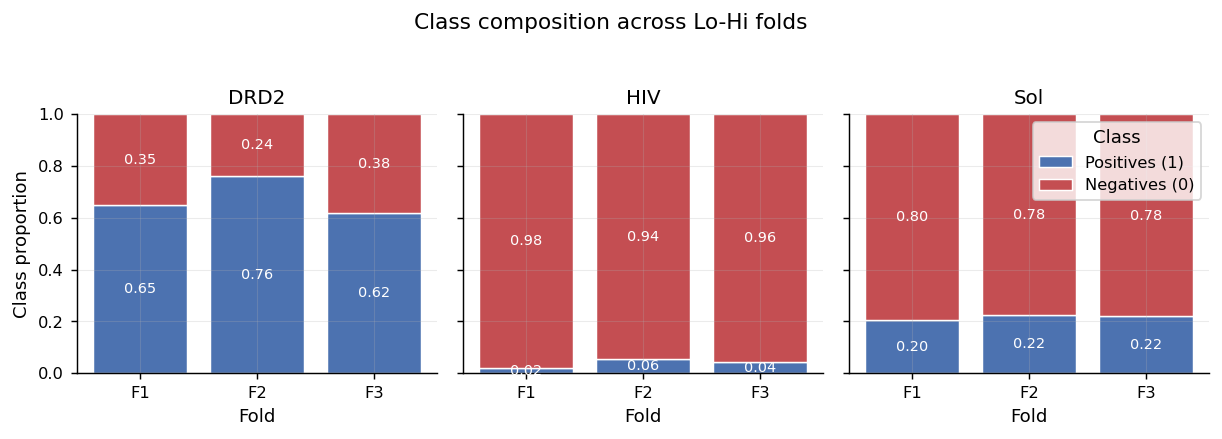

In [4]:
# Class composition by dataset and fold

rows = []

for ds in DATASETS:
    for fold, fname in SUBSET_FILES.items():
        df = pd.read_csv(PROJECT_ROOT / "data" / TASK / ds / fname)
        y = pd.to_numeric(df["value"], errors="coerce").dropna().astype(int)

        rows.append(
            {
                "dataset": ds,
                "dataset_label": DATASET_LABELS[ds],
                "fold": fold,
                "n": len(y),
                "positive_rate": (y == 1).mean(),
                "negative_rate": (y == 0).mean(),
            }
        )

class_balance = pd.DataFrame(rows)
class_balance["fold"] = pd.Categorical(
    class_balance["fold"], categories=FOLDS, ordered=True
)
class_balance = class_balance.sort_values(["dataset", "fold"])

display(class_balance)

fig, axes = plt.subplots(1, 3, figsize=(9.5, 3.2), sharey=True)

pos_color = "#4C72B0"
neg_color = "#C44E52"

for ax, ds in zip(axes, DATASET_ORDER):
    sub = class_balance[class_balance["dataset"] == ds].sort_values("fold")
    x = np.arange(len(sub))

    ax.bar(
        x,
        sub["positive_rate"],
        color=pos_color,
        edgecolor="white",
        linewidth=0.8,
        label="Positives (1)",
    )

    ax.bar(
        x,
        sub["negative_rate"],
        bottom=sub["positive_rate"],
        color=neg_color,
        edgecolor="white",
        linewidth=0.8,
        label="Negatives (0)",
    )

    ax.set_title(DATASET_LABELS[ds])
    ax.set_xticks(x)
    ax.set_xticklabels(sub["fold"].astype(str))
    ax.set_xlabel("Fold")
    ax.set_ylim(0, 1)

    for xi, pos, neg in zip(x, sub["positive_rate"], sub["negative_rate"]):
        ax.text(
            xi,
            pos / 2,
            f"{pos:.2f}",
            ha="center",
            va="center",
            fontsize=8,
            color="white",
        )
        ax.text(
            xi,
            pos + neg / 2,
            f"{neg:.2f}",
            ha="center",
            va="center",
            fontsize=8,
            color="white",
        )

    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("Class proportion")
axes[-1].legend(title="Class", frameon=True, loc="upper right")

fig.suptitle("Class composition across Lo-Hi folds", y=1.04)
fig.tight_layout()

save_fig(fig, "fig1_class_composition_by_fold")
plt.show()

## 2. Activity-rule stability across folds

Here the question is whether the model learns the same activity rule across the three Lo-Hi folds. I use RBO as the primary metric because it is top-weighted and more appropriate for sparse feature rankings. Kendall's tau-b is reported only as a companion metric.

High RBO means the top activity features are stable across folds. Low RBO is compatible with rule instability, but I do not interpret it as direct proof of concept shift.


Regola stabile tra fold
→ il modello usa più o meno gli stessi bit/feature
→ lo shift può essere più compatibile con covariate shift

Regola instabile tra fold
→ il modello cambia le feature importanti da fold a fold
→ può indicare instabilità della relazione feature → activity
→ compatibile con possibile concept / conditional shift


Rank-Biased Overlap --> perchè ci interessano di più i top bit, non se il bit 1800 e bit 1900 si scambiano
La domanda è le feature più importanti per il modello sono stabili tra fold? e non tutti i 2048 bit sono ordinati nello stesso identico modo?

#### Before asking whether OOD validation improves model selection, I check whether the activity rule itself is stable across Lo-Hi folds. If the top-ranked activity features remain similar across folds, then the model is learning a stable rule under distribution shift. If the rankings change substantially, then the shift may involve instability in the learned feature-activity relationship.

In [5]:
def importance_for_model(df: pd.DataFrame, model: str) -> pd.Series:
    # DT uses tree importance; linear models use coefficient magnitude
    if model == "DT" and "tree_importance" in df.columns:
        return (
            pd.to_numeric(df["tree_importance"], errors="coerce")
            .fillna(0.0)
            .clip(lower=0.0)
        )
    for c in [
        "normalized_abs_importance",
        "abs_weight",
        "importance_value",
        "coefficient",
    ]:
        if c in df.columns:
            v = pd.to_numeric(df[c], errors="coerce").fillna(0.0)
            return v.abs()
    raise ValueError(f"No usable importance column for model={model}")


def ranking_list(
    df: pd.DataFrame, dataset: str, model: str, fold: int, protocol: str = "ood"
) -> list[int]:
    sub = df[
        (df["dataset"] == dataset)
        & (df["model"] == model)
        & (df["fold"].astype(int) == int(fold))
        & (df["protocol_norm"] == protocol)
    ].copy()
    if sub.empty:
        return []
    sub["rank_importance"] = importance_for_model(sub, model)
    sub = sub[sub["rank_importance"] > 0].copy()
    sub["feature_idx"] = sub["feature_idx"].astype(int)
    sub = sub.sort_values(["rank_importance", "feature_idx"], ascending=[False, True])
    return sub["feature_idx"].tolist()


def rbo_score(
    s: list[int], t: list[int], p: float = 0.90, depth: int | None = None
) -> float:
    # Finite-depth RBO, enough for comparing top feature lists
    if depth is None:
        depth = max(len(s), len(t))
    if depth == 0:
        return np.nan
    s_seen, t_seen = set(), set()
    score = 0.0
    for d in range(1, depth + 1):
        if d <= len(s):
            s_seen.add(s[d - 1])
        if d <= len(t):
            t_seen.add(t[d - 1])
        agreement = len(s_seen & t_seen) / d
        score += agreement * (p ** (d - 1))
    return float((1 - p) * score)


def tau_on_union_topk(s: list[int], t: list[int], k: int = 100) -> float:
    s_top = s[:k]
    t_top = t[:k]
    universe = sorted(set(s_top) | set(t_top))
    if len(universe) < 2:
        return np.nan
    s_rank = {f: i + 1 for i, f in enumerate(s_top)}
    t_rank = {f: i + 1 for i, f in enumerate(t_top)}
    missing = k + 1
    a = [s_rank.get(f, missing) for f in universe]
    b = [t_rank.get(f, missing) for f in universe]
    tau, _ = kendalltau(a, b)
    return float(tau) if pd.notna(tau) else np.nan


def build_ranking_stability(
    feature_df: pd.DataFrame, top_k: int = 100, p: float = 0.90
) -> pd.DataFrame:
    rows = []
    for ds in DATASETS:
        for model in RANKING_MODELS:
            ranks = {
                fold: ranking_list(feature_df, ds, model, fold=i + 1, protocol="ood")
                for i, fold in enumerate(FOLDS)
            }
            for fa, fb in combinations(FOLDS, 2):
                s, t = ranks[fa], ranks[fb]
                rows.append(
                    {
                        "dataset": ds,
                        "dataset_label": DATASET_LABELS[ds],
                        "model": model,
                        "fold_a": fa,
                        "fold_b": fb,
                        "pair": f"{fa}_vs_{fb}",
                        "rbo": rbo_score(s[:top_k], t[:top_k], p=p, depth=top_k),
                        "kendall_tau_topk": tau_on_union_topk(s, t, k=top_k),
                        "n_pos_a": len(s),
                        "n_pos_b": len(t),
                        "top_k": top_k,
                        "rbo_p": p,
                    }
                )
    pairwise = pd.DataFrame(rows)
    summary = (
        pairwise.groupby(["dataset", "dataset_label", "model"], as_index=False)
        .agg(
            mean_rbo=("rbo", "mean"),
            std_rbo=("rbo", "std"),
            mean_tau=("kendall_tau_topk", "mean"),
            std_tau=("kendall_tau_topk", "std"),
            min_positive_features=("n_pos_a", "min"),
            max_positive_features=("n_pos_a", "max"),
        )
        .sort_values(["dataset", "model"])
    )
    pairwise.to_csv(TAB_DIR / "tab2_ranking_stability_pairwise.csv", index=False)
    summary.to_csv(TAB_DIR / "tab2_ranking_stability_summary.csv", index=False)
    return pairwise, summary


rank_pairwise, tab2_ranking_stability = build_ranking_stability(
    feature_importance, top_k=100, p=0.90
)
display(tab2_ranking_stability)

,dataset,dataset_label,model,mean_rbo,std_rbo,mean_tau,std_tau,min_positive_features,max_positive_features
0,drd2,DRD2,DT,0.089587,0.149219,-0.391790,0.118827,7,115
1,drd2,DRD2,LR,0.093322,0.044067,-0.376344,0.129953,395,1969
2,drd2,DRD2,SVM,0.063032,0.056881,-0.447293,0.119434,1787,1866
3,hiv,HIV,DT,0.147888,0.137725,-0.465451,0.125089,16,24
4,hiv,HIV,LR,0.068722,0.013775,-0.426658,0.031993,997,1844
5,hiv,HIV,SVM,0.098066,0.116667,-0.530379,0.083734,2045,2048
6,sol,Sol,DT,0.089500,0.053110,-0.475767,0.048558,35,77
7,sol,Sol,LR,0.193818,0.130311,-0.259880,0.062590,2021,2031
8,sol,Sol,SVM,0.072526,0.097796,-0.424333,0.108288,1915,1921


Saved: /home/f.capria/drug-discovery-lohi/results/results_main_diagnostic_notebook/hi/figures/fig2_ranking_stability_rbo_tau_top100.pdf
Saved: /home/f.capria/drug-discovery-lohi/results/results_main_diagnostic_notebook/hi/figures/fig2_ranking_stability_rbo_tau_top100.png


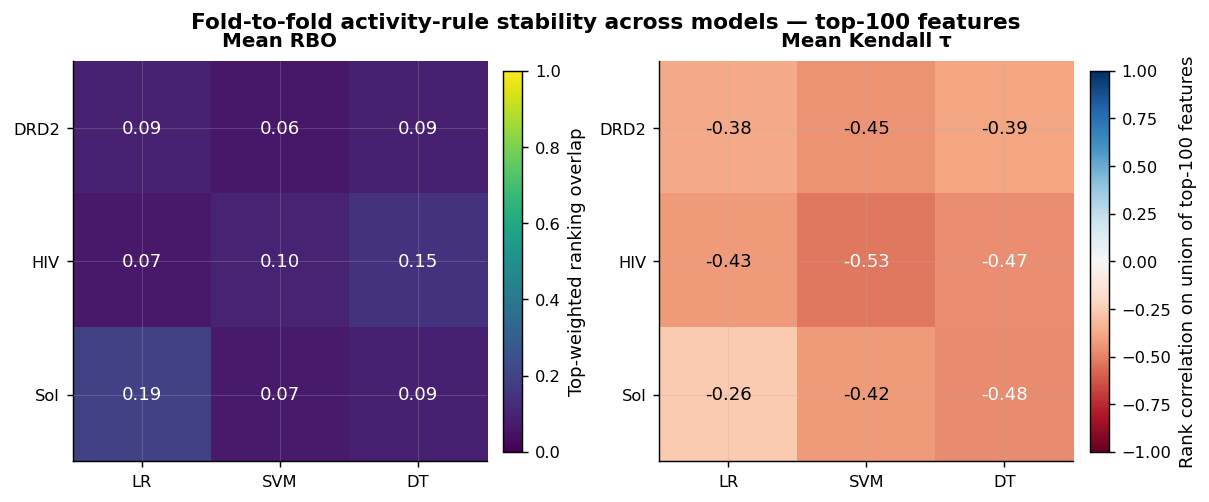

In [6]:
def fig_ranking_stability(summary: pd.DataFrame, top_k: int = 100) -> None:
    row_order = [DATASET_LABELS[d] for d in DATASET_ORDER]
    col_order = [m for m in RANKING_MODELS if m in summary["model"].unique()]

    rbo_mat = summary.pivot(
        index="dataset_label", columns="model", values="mean_rbo"
    ).reindex(index=row_order, columns=col_order)

    tau_mat = summary.pivot(
        index="dataset_label", columns="model", values="mean_tau"
    ).reindex(index=row_order, columns=col_order)

    fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.6), constrained_layout=True)

    panels = [
        (
            axes[0],
            rbo_mat,
            "Mean RBO",
            "viridis",
            0.0,
            1.0,
            "Top-weighted ranking overlap",
        ),
        (
            axes[1],
            tau_mat,
            "Mean Kendall τ",
            "RdBu",
            -1.0,
            1.0,
            "Rank correlation on union of top-100 features",
        ),
    ]

    for ax, mat, title, cmap, vmin, vmax, cbar_label in panels:
        im = ax.imshow(
            mat.values.astype(float), cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto"
        )

        ax.set_title(title, fontweight="bold", pad=8)
        ax.set_xticks(np.arange(mat.shape[1]))
        ax.set_xticklabels(mat.columns)
        ax.set_yticks(np.arange(mat.shape[0]))
        ax.set_yticklabels(mat.index)

        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                v = mat.iloc[i, j]
                if pd.isna(v):
                    txt = "NA"
                    color = "black"
                else:
                    txt = f"{v:.2f}"
                    if title == "Mean RBO":
                        color = "white" if v < 0.45 else "black"
                    else:
                        color = "white" if abs(v) > 0.45 else "black"

                ax.text(j, i, txt, ha="center", va="center", fontsize=10, color=color)

        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label(cbar_label)

    fig.suptitle(
        f"Fold-to-fold activity-rule stability across models — top-{top_k} features",
        fontweight="bold",
        y=1.03,
    )

    save_fig(fig, "fig2_ranking_stability_rbo_tau_top100")
    plt.show()


fig_ranking_stability(tab2_ranking_stability, top_k=100)

## 3a. Covariate localization: full ECFP4 fold distance

As a first reference, I inspect the fold-to-fold Tanimoto distance in the full ECFP4 space.  
This gives the baseline geometric separation between folds before restricting the representation to activity-relevant bits.

Saved: /home/f.capria/drug-discovery-lohi/results/results_main_diagnostic_notebook/hi/figures/fig3a_full_ecfp4_fold_distance_heatmap.pdf
Saved: /home/f.capria/drug-discovery-lohi/results/results_main_diagnostic_notebook/hi/figures/fig3a_full_ecfp4_fold_distance_heatmap.png


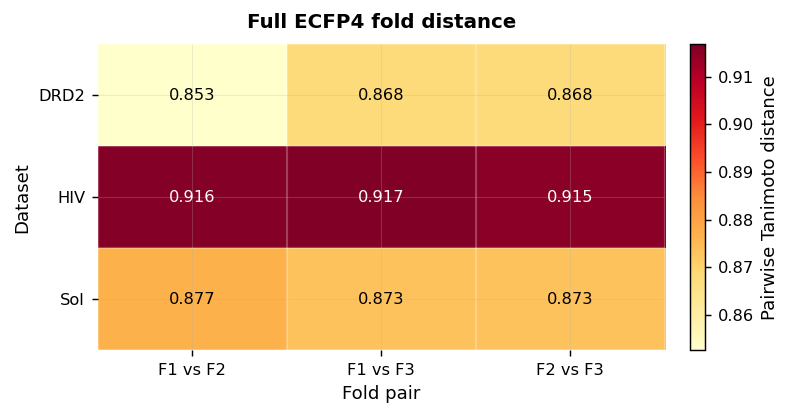

In [7]:
def fig_full_fold_distance_heatmap(dist_df: pd.DataFrame) -> None:
    full_df = dist_df[dist_df["bit_source"] == "full_ecfp4"].copy()

    if full_df.empty:
        print("No full ECFP4 rows available.")
        return

    # Full ECFP4 distance is independent of the model.
    # It is repeated for DT/LR/SVM only to keep the table aligned.
    full_df = full_df.drop_duplicates(["dataset", "dataset_label", "pair"])

    pair_order = ["F1_vs_F2", "F1_vs_F3", "F2_vs_F3"]
    pair_labels = ["F1 vs F2", "F1 vs F3", "F2 vs F3"]
    row_order = [DATASET_LABELS[d] for d in DATASET_ORDER]

    mat = full_df.pivot(
        index="dataset_label", columns="pair", values="pairwise_distance_mean"
    ).reindex(index=row_order, columns=pair_order)

    vals = mat.values.astype(float)
    vmin = np.nanmin(vals)
    vmax = np.nanmax(vals)

    fig, ax = plt.subplots(figsize=(6.2, 3.3))

    im = ax.imshow(
        vals,
        cmap="YlOrRd",
        vmin=vmin,
        vmax=vmax,
        aspect="auto",
    )

    ax.set_xticks(np.arange(len(pair_order)))
    ax.set_xticklabels(pair_labels)
    ax.set_yticks(np.arange(len(row_order)))
    ax.set_yticklabels(row_order)

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat.iloc[i, j]
            txt = "NA" if pd.isna(v) else f"{v:.3f}"
            color = "white" if pd.notna(v) and v > (vmin + vmax) / 2 else "black"
            ax.text(j, i, txt, ha="center", va="center", fontsize=9, color=color)

    ax.set_title("Full ECFP4 fold distance", fontweight="bold", pad=9)
    ax.set_xlabel("Fold pair")
    ax.set_ylabel("Dataset")

    ax.set_xticks(np.arange(-0.5, len(pair_order), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(row_order), 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.2)
    ax.tick_params(which="minor", bottom=False, left=False)

    ax.spines[["top", "right", "bottom", "left"]].set_visible(False)

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Pairwise Tanimoto distance")

    fig.tight_layout()

    save_fig(fig, "fig3a_full_ecfp4_fold_distance_heatmap")
    plt.show()


fig_full_fold_distance_heatmap(tanimoto_summary)

## Activity-restricted fold distance vs k

I now compare the fold distance measured in activity-relevant subspaces.  
For each dataset and model, I show how the mean pairwise Tanimoto distance evolves as I increase the number of selected ECFP4 bits.

The dotted horizontal lines indicate the corresponding full-ECFP4 fold distance for the same fold pair.

Saved: /home/f.capria/drug-discovery-lohi/results/results_main_diagnostic_notebook/hi/figures/fig3b_activity_restricted_fold_distance_compact_grid.pdf
Saved: /home/f.capria/drug-discovery-lohi/results/results_main_diagnostic_notebook/hi/figures/fig3b_activity_restricted_fold_distance_compact_grid.png


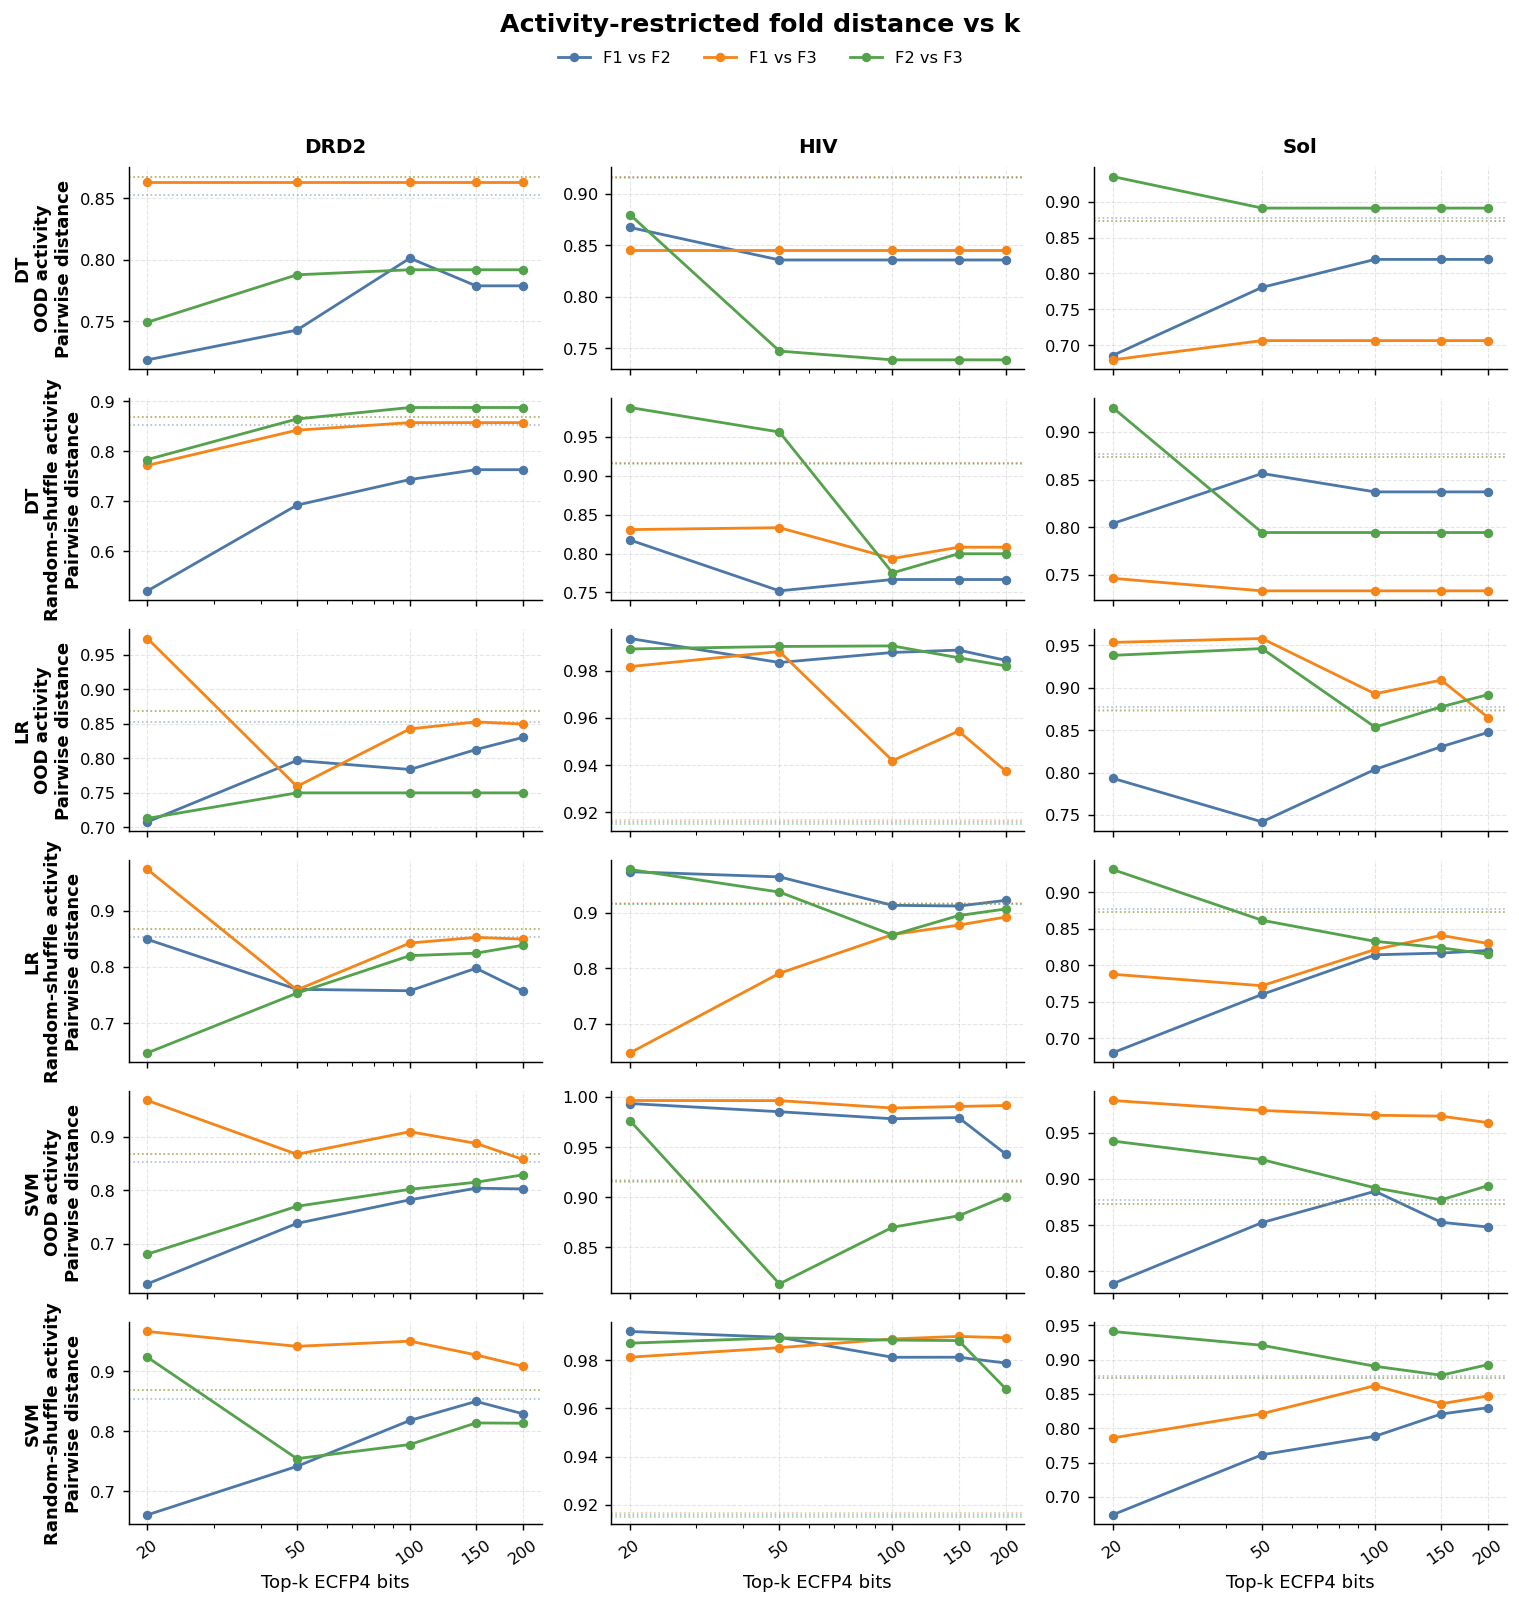

In [8]:
def fig_activity_restricted_distance_compact_grid(dist_df: pd.DataFrame) -> None:
    row_specs = []
    for model in ALL_MODELS:
        if model in dist_df["model"].unique():
            row_specs.extend(
                [
                    (model, "activity_ood", "OOD activity"),
                    (model, "activity_random_shuffle", "Random-shuffle activity"),
                ]
            )

    n_rows = len(row_specs)
    n_cols = len(DATASET_ORDER)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(11.8, 12.0),
        sharex=True,
        sharey=False,
        squeeze=False,
    )

    pair_order = ["F1_vs_F2", "F1_vs_F3", "F2_vs_F3"]
    pair_labels = {
        "F1_vs_F2": "F1 vs F2",
        "F1_vs_F3": "F1 vs F3",
        "F2_vs_F3": "F2 vs F3",
    }

    pair_colors = {
        "F1_vs_F2": "#4C78A8",
        "F1_vs_F3": "#F58518",
        "F2_vs_F3": "#54A24B",
    }

    k_plot = [20, 50, 100, 150, 200]

    for i, (model, src, src_label) in enumerate(row_specs):
        for j, ds in enumerate(DATASET_ORDER):
            ax = axes[i, j]

            sub_all = dist_df[
                (dist_df["dataset"] == ds)
                & (dist_df["model"] == model)
                & (dist_df["bit_source"] == src)
                & (dist_df["k"].astype(int).isin(k_plot))
            ].copy()

            for pair in pair_order:
                sub = sub_all[sub_all["pair"] == pair].sort_values("k")

                if sub.empty:
                    continue

                ax.plot(
                    sub["k"].astype(int),
                    sub["pairwise_distance_mean"],
                    marker="o",
                    markersize=4.2,
                    lw=1.55,
                    color=pair_colors[pair],
                    label=pair_labels[pair],
                )

                full_ref = sub["full_pairwise_distance_mean"].dropna()
                if len(full_ref) > 0:
                    ax.axhline(
                        float(full_ref.iloc[0]),
                        ls=":",
                        lw=0.9,
                        color=pair_colors[pair],
                        alpha=0.50,
                    )

            ax.set_xscale("log")
            ax.set_xticks(k_plot)
            ax.set_xticklabels([str(k) for k in k_plot], rotation=35)
            ax.grid(ls="--", alpha=0.32)

            if i == 0:
                ax.set_title(
                    DATASET_LABELS.get(ds, ds),
                    fontweight="bold",
                    pad=8,
                )

            if j == 0:
                ax.set_ylabel(
                    f"{model}\n{src_label}\nPairwise distance",
                    fontweight="bold",
                )

            if i == n_rows - 1:
                ax.set_xlabel("Top-k ECFP4 bits")

    handles, labels = axes[0, 0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=3,
        frameon=False,
        bbox_to_anchor=(0.5, 1.01),
    )

    fig.suptitle(
        "Activity-restricted fold distance vs k",
        y=1.025,
        fontweight="bold",
        fontsize=14,
    )

    fig.tight_layout(rect=[0, 0, 1, 0.985])

    save_fig(
        fig,
        "fig3b_activity_restricted_fold_distance_compact_grid",
    )

    plt.show()
    plt.close(fig)


fig_activity_restricted_distance_compact_grid(tanimoto_summary)

In [9]:
def build_step3a_recap_table(dist_df: pd.DataFrame, top_k: int = 100) -> pd.DataFrame:
    sources = {
        "activity_ood": "activity_ood",
        "activity_random_shuffle": "activity_random",
        "dataset_detection": "fold_discriminator",
    }

    df = dist_df.copy()
    df["k"] = df["k"].astype(int)

    # Full ECFP4 is model-independent, so keep one copy per dataset/pair
    full = (
        df[df["bit_source"] == "full_ecfp4"]
        .drop_duplicates(["dataset", "dataset_label", "pair"])
        .groupby(["dataset", "dataset_label"], as_index=False)
        .agg(full_ecfp4_distance=("pairwise_distance_mean", "mean"))
    )

    # Random bits are also model-independent in the output, so keep one copy per dataset/pair/k
    random_bits = (
        df[(df["bit_source"] == "random_bits") & (df["k"] == top_k)]
        .drop_duplicates(["dataset", "dataset_label", "pair"])
        .groupby(["dataset", "dataset_label"], as_index=False)
        .agg(random_bits_distance=("pairwise_distance_mean", "mean"))
    )

    sub = df[(df["k"] == top_k) & (df["bit_source"].isin(sources.keys()))].copy()

    sub["source"] = sub["bit_source"].map(sources)

    recap_long = sub.groupby(
        ["dataset", "dataset_label", "model", "source"], as_index=False
    ).agg(
        distance=("pairwise_distance_mean", "mean"),
        bits_used=("bits_used_mean", "mean"),
        valid_fraction=("valid_molecule_fraction_mean", "mean"),
        main_safe_pairs=("high_coverage_recommended_for_main_plot", "sum"),
    )

    distance_wide = recap_long.pivot(
        index=["dataset", "dataset_label", "model"], columns="source", values="distance"
    ).reset_index()

    bits_wide = recap_long.pivot(
        index=["dataset", "dataset_label", "model"],
        columns="source",
        values="bits_used",
    ).reset_index()

    bits_wide = bits_wide.rename(
        columns={c: f"{c}_bits" for c in sources.values() if c in bits_wide.columns}
    )

    safe_wide = recap_long.pivot(
        index=["dataset", "dataset_label", "model"],
        columns="source",
        values="main_safe_pairs",
    ).reset_index()

    safe_wide = safe_wide.rename(
        columns={
            c: f"{c}_safe_pairs" for c in sources.values() if c in safe_wide.columns
        }
    )

    tab = (
        distance_wide.merge(
            bits_wide, on=["dataset", "dataset_label", "model"], how="left"
        )
        .merge(safe_wide, on=["dataset", "dataset_label", "model"], how="left")
        .merge(full, on=["dataset", "dataset_label"], how="left")
        .merge(random_bits, on=["dataset", "dataset_label"], how="left")
    )

    tab["activity_ood_minus_full"] = tab["activity_ood"] - tab["full_ecfp4_distance"]
    tab["activity_ood_minus_random_bits"] = (
        tab["activity_ood"] - tab["random_bits_distance"]
    )
    tab["fold_discriminator_minus_full"] = (
        tab["fold_discriminator"] - tab["full_ecfp4_distance"]
    )

    tab["dataset"] = pd.Categorical(
        tab["dataset"], categories=DATASET_ORDER, ordered=True
    )
    tab["model"] = pd.Categorical(tab["model"], categories=ALL_MODELS, ordered=True)

    tab = tab.sort_values(["dataset", "model"]).reset_index(drop=True)

    numeric_cols = tab.select_dtypes(include="number").columns
    tab[numeric_cols] = tab[numeric_cols].round(4)

    tab.to_csv(
        TAB_DIR / f"tab3a_covariate_localization_recap_top{top_k}.csv", index=False
    )

    return tab


tab3a_covariate_localization = build_step3a_recap_table(tanimoto_summary, top_k=100)
display(tab3a_covariate_localization)

,dataset,dataset_label,model,activity_ood,activity_random,fold_discriminator,activity_ood_bits,activity_random_bits,fold_discriminator_bits,activity_ood_safe_pairs,activity_random_safe_pairs,fold_discriminator_safe_pairs,full_ecfp4_distance,random_bits_distance,activity_ood_minus_full,activity_ood_minus_random_bits,fold_discriminator_minus_full
0,drd2,DRD2,DT,0.8190,0.8295,0.7797,54.0000,77.0000,53.6667,1,1,0,0.8627,0.8650,-0.0437,-0.0460,-0.0830
1,drd2,DRD2,LR,0.7920,0.8067,0.8651,77.3333,100.0000,100.0000,2,3,3,0.8627,0.8650,-0.0707,-0.0730,0.0025
2,drd2,DRD2,SVM,0.8312,0.8484,0.8624,100.0000,100.0000,100.0000,3,3,3,0.8627,0.8650,-0.0315,-0.0338,-0.0003
3,hiv,HIV,DT,0.8066,0.7784,0.8163,32.0000,86.3333,74.6667,0,0,0,0.9159,0.9080,-0.1093,-0.1014,-0.0996
4,hiv,HIV,LR,0.9734,0.8780,0.8696,100.0000,100.0000,100.0000,0,0,0,0.9159,0.9080,0.0575,0.0654,-0.0463
5,hiv,HIV,SVM,0.9458,0.9861,0.7859,100.0000,100.0000,100.0000,0,0,0,0.9159,0.9080,0.0299,0.0378,-0.1300
6,sol,Sol,DT,0.8057,0.7882,0.7770,50.6667,58.3333,41.3333,0,0,0,0.8744,0.8706,-0.0687,-0.0649,-0.0974
7,sol,Sol,LR,0.8501,0.8227,0.8701,100.0000,100.0000,100.0000,1,1,0,0.8744,0.8706,-0.0243,-0.0205,-0.0043
8,sol,Sol,SVM,0.9153,0.8469,0.8475,100.0000,100.0000,100.0000,1,1,1,0.8744,0.8706,0.0409,0.0447,-0.0270


## 3b. Concept-instability probe: train, validation, and test gaps

This section checks whether high train/validation performance collapses on the outer OOD test fold. I keep all datasets in the plots and highlight HIV, instead of hard-routing datasets before seeing the diagnostics.

The three scatter plots are deliberately separated: train vs validation, validation vs test, and train vs test.

In [10]:
from matplotlib.lines import Line2D


def get_protocol_summary() -> pd.DataFrame:
    needed = {
        "dataset",
        "model",
        "protocol",
        "fingerprint",
        "train_mean",
        "inner_mean",
        "test_mean",
    }

    for name, obj in globals().items():
        if isinstance(obj, pd.DataFrame) and needed.issubset(obj.columns):
            print(f"Using dataframe already in memory: {name}")
            return obj.copy()

    search_dir = (
        PROJECT_ROOT
        / "results"
        / "results_ood_vs_random_shuffle"
        / "hi"
        / "cross_dataset"
    )

    for path in sorted(search_dir.glob("*.csv")):
        df = pd.read_csv(path)
        if needed.issubset(df.columns):
            print(f"Loaded summary from: {path.name}")
            return df.copy()

    raise ValueError("No summary table found.")


summary = get_protocol_summary()

print("Protocols:", summary["protocol"].unique())
print("Models:", summary["model"].unique())
print("Fingerprints:", summary["fingerprint"].unique())

display(summary.head())

Using dataframe already in memory: protocol_summary
Protocols: <StringArray>
['OOD holdout', 'Random shuffle']
Length: 2, dtype: str
Models: <StringArray>
['DT', 'LR', 'SVM']
Length: 3, dtype: str
Fingerprints: <StringArray>
['ecfp4']
Length: 1, dtype: str


,dataset,dataset_label,model,model_short,fingerprint,protocol,inner_mean,inner_std,train_mean,train_std,...,test_std,inner_test_gap_mean,inner_test_gap_std,train_test_gap_mean,train_test_gap_std,dataset_order,model_order,fingerprint_order,protocol_order,protocol_norm
0,drd2,DRD2,DT,DT,ecfp4,OOD holdout,0.759534,0.079553,0.873600,0.094134,...,0.071800,0.036401,0.146231,0.150467,0.165873,0,0,0,0,ood
1,drd2,DRD2,DT,DT,ecfp4,Random shuffle,0.870081,0.037981,0.886033,0.042257,...,0.045379,0.182114,0.079506,0.198067,0.076944,0,0,0,1,random
4,drd2,DRD2,LR,LR,ecfp4,OOD holdout,0.754639,0.100830,0.949400,0.044530,...,0.083300,0.009572,0.178359,0.204333,0.066570,0,1,0,0,ood
5,drd2,DRD2,LR,LR,ecfp4,Random shuffle,0.914718,0.027637,0.985067,0.009160,...,0.090125,0.149918,0.117160,0.220267,0.095655,0,1,0,1,random
10,drd2,DRD2,SVM,SVM,ecfp4,OOD holdout,0.734990,0.085945,0.944033,0.027383,...,0.097561,-0.017043,0.179443,0.192000,0.092979,0,2,0,0,ood


Saved: /home/f.capria/drug-discovery-lohi/results/results_main_diagnostic_notebook/hi/figures/fig3b_train_vs_test_scatter.pdf
Saved: /home/f.capria/drug-discovery-lohi/results/results_main_diagnostic_notebook/hi/figures/fig3b_train_vs_test_scatter.png


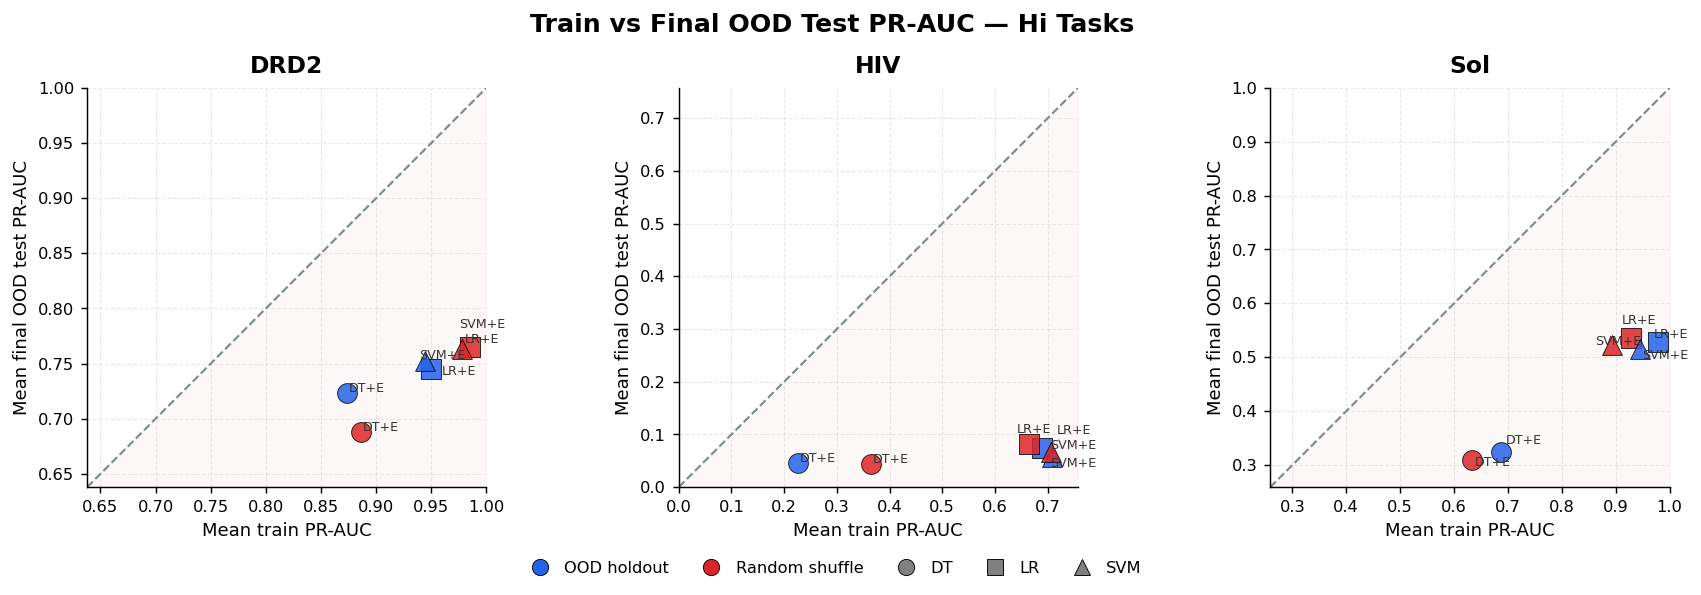

Saved: /home/f.capria/drug-discovery-lohi/results/results_main_diagnostic_notebook/hi/figures/fig3b_inner_vs_test_scatter.pdf
Saved: /home/f.capria/drug-discovery-lohi/results/results_main_diagnostic_notebook/hi/figures/fig3b_inner_vs_test_scatter.png


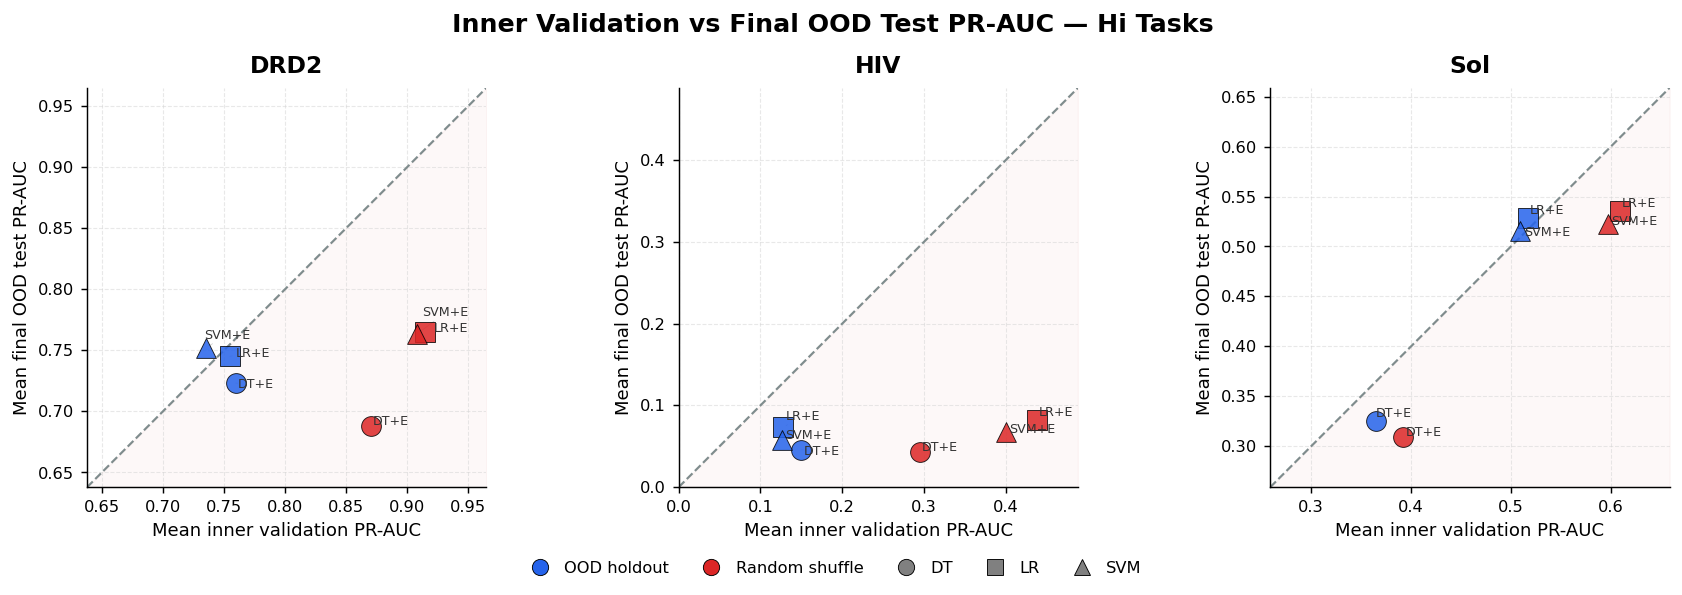

Saved: /home/f.capria/drug-discovery-lohi/results/results_main_diagnostic_notebook/hi/figures/fig3b_train_vs_inner_scatter.pdf
Saved: /home/f.capria/drug-discovery-lohi/results/results_main_diagnostic_notebook/hi/figures/fig3b_train_vs_inner_scatter.png


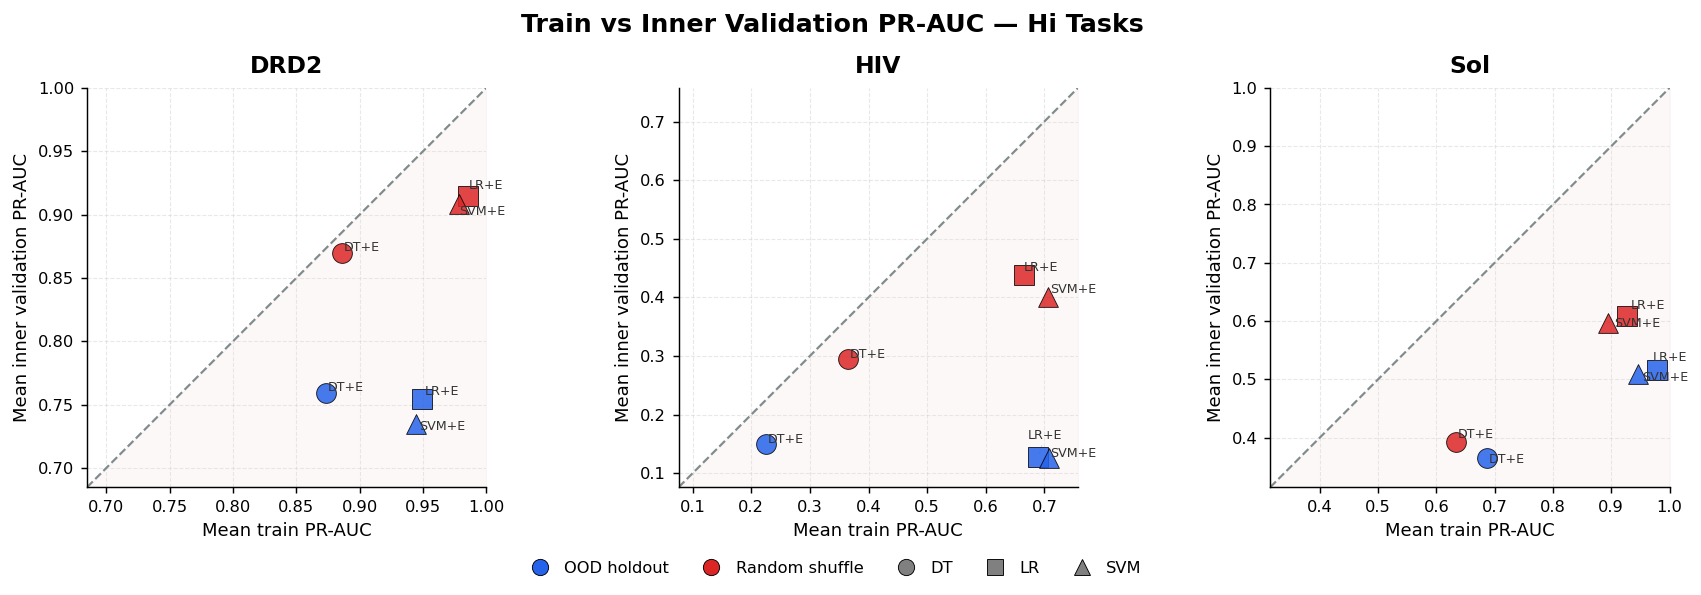

In [11]:
def plot_metric_scatter_like_original(
    summary: pd.DataFrame,
    x_col: str,
    y_col: str,
    x_label: str,
    y_label: str,
    title: str,
    filename: str,
) -> None:

    datasets = [d for d in DATASET_ORDER if d in summary["dataset"].unique()]
    n = len(datasets)

    fig, axes = plt.subplots(
        1,
        n,
        figsize=(4.7 * n, 4.8),
        squeeze=False,
    )

    for idx, dataset in enumerate(datasets):
        ax = axes[0, idx]
        sub = summary[summary["dataset"] == dataset].copy()

        all_vals = pd.concat([sub[x_col], sub[y_col]]).dropna()
        lo = max(0, all_vals.min() - 0.05)
        hi = min(1, all_vals.max() + 0.05)
        lims = [lo, hi]

        ax.set_axisbelow(True)
        ax.grid(True, linestyle="--", color="lightgrey", alpha=0.5, zorder=0)

        ax.plot(lims, lims, ls="--", lw=1.2, color="#7f8c8d", zorder=1)

        ax.fill_between(
            lims,
            lims,
            [lims[0], lims[0]],
            alpha=0.03,
            color="#c0392b",
            zorder=0,
        )

        for _, row in sub.iterrows():
            protocol = row["protocol"]
            model = row["model"]

            ax.scatter(
                row[x_col],
                row[y_col],
                c=PROTOCOL_COLORS.get(protocol, "grey"),
                marker=MODEL_MARKERS.get(model, "o"),
                s=120,
                edgecolors="black",
                linewidths=0.5,
                alpha=0.85,
                zorder=3,
            )

        try:
            from adjustText import adjust_text
        except ImportError as exc:
            raise ImportError(
                "This figure requires the adjustText package. Install it with: pip install adjustText"
            ) from exc

        texts = []

        for _, row in sub.iterrows():
            ms = MODEL_SHORT.get(row["model"], str(row["model"])[:2])

            fp = str(row["fingerprint"])
            if fp == "RDKit desc" or "rdkit_desc" in fp.lower():
                fp_short = "R"
            elif "maccs" in fp.lower():
                fp_short = "M"
            elif "ecfp" in fp.lower():
                fp_short = "E"
            elif "topo" in fp.lower():
                fp_short = "T"
            else:
                fp_short = fp[:1]

            label = f"{ms}+{fp_short}"

            texts.append(
                ax.text(
                    row[x_col],
                    row[y_col],
                    label,
                    fontsize=7,
                    color="#333333",
                )
            )

        adjust_text(
            texts,
            ax=ax,
            arrowprops=dict(
                arrowstyle="-",
                color="grey",
                lw=0.4,
                alpha=0.4,
            ),
        )

        ax.set_xlim(lims)
        ax.set_ylim(lims)
        ax.set_aspect("equal")

        ax.set_xlabel(x_label, fontsize=10)
        ax.set_ylabel(y_label, fontsize=10)

        ax.set_title(
            DATASET_LABELS.get(dataset, dataset),
            fontsize=13,
            fontweight="bold",
            pad=8,
        )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    used_protocols = list(dict.fromkeys(summary["protocol"].tolist()))

    protocol_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            markerfacecolor=PROTOCOL_COLORS.get(p, "grey"),
            markersize=9,
            markeredgecolor="black",
            markeredgewidth=0.5,
            label=PROTOCOL_LABELS.get(p, p),
        )
        for p in used_protocols
    ]

    used_models = [m for m in MODEL_MARKERS if m in summary["model"].unique()]

    model_handles = [
        Line2D(
            [0],
            [0],
            marker=MODEL_MARKERS[m],
            color="w",
            markerfacecolor="grey",
            markersize=9,
            markeredgecolor="black",
            markeredgewidth=0.5,
            label=MODEL_SHORT.get(m, m),
        )
        for m in used_models
    ]

    fig.suptitle(
        title,
        fontsize=14,
        fontweight="bold",
        y=0.98,
    )

    fig.subplots_adjust(
        left=0.07,
        right=0.98,
        top=0.86,
        bottom=0.22,
        wspace=0.22,
    )

    fig.legend(
        handles=protocol_handles + model_handles,
        loc="lower center",
        ncol=5,
        fontsize=9,
        bbox_to_anchor=(0.5, 0.055),
        frameon=False,
        columnspacing=1.6,
        handletextpad=0.5,
    )

    save_fig(fig, filename)

    plt.show()
    plt.close(fig)


plot_metric_scatter_like_original(
    summary,
    x_col="train_mean",
    y_col="test_mean",
    x_label="Mean train PR-AUC",
    y_label="Mean final OOD test PR-AUC",
    title="Train vs Final OOD Test PR-AUC — Hi Tasks",
    filename="fig3b_train_vs_test_scatter",
)

plot_metric_scatter_like_original(
    summary,
    x_col="inner_mean",
    y_col="test_mean",
    x_label="Mean inner validation PR-AUC",
    y_label="Mean final OOD test PR-AUC",
    title="Inner Validation vs Final OOD Test PR-AUC — Hi Tasks",
    filename="fig3b_inner_vs_test_scatter",
)

plot_metric_scatter_like_original(
    summary,
    x_col="train_mean",
    y_col="inner_mean",
    x_label="Mean train PR-AUC",
    y_label="Mean inner validation PR-AUC",
    title="Train vs Inner Validation PR-AUC — Hi Tasks",
    filename="fig3b_train_vs_inner_scatter",
)

Saved: /home/f.capria/drug-discovery-lohi/results/results_main_diagnostic_notebook/hi/figures/fig3b_foldwise_ood_performance_gaps_ecfp4.pdf
Saved: /home/f.capria/drug-discovery-lohi/results/results_main_diagnostic_notebook/hi/figures/fig3b_foldwise_ood_performance_gaps_ecfp4.png


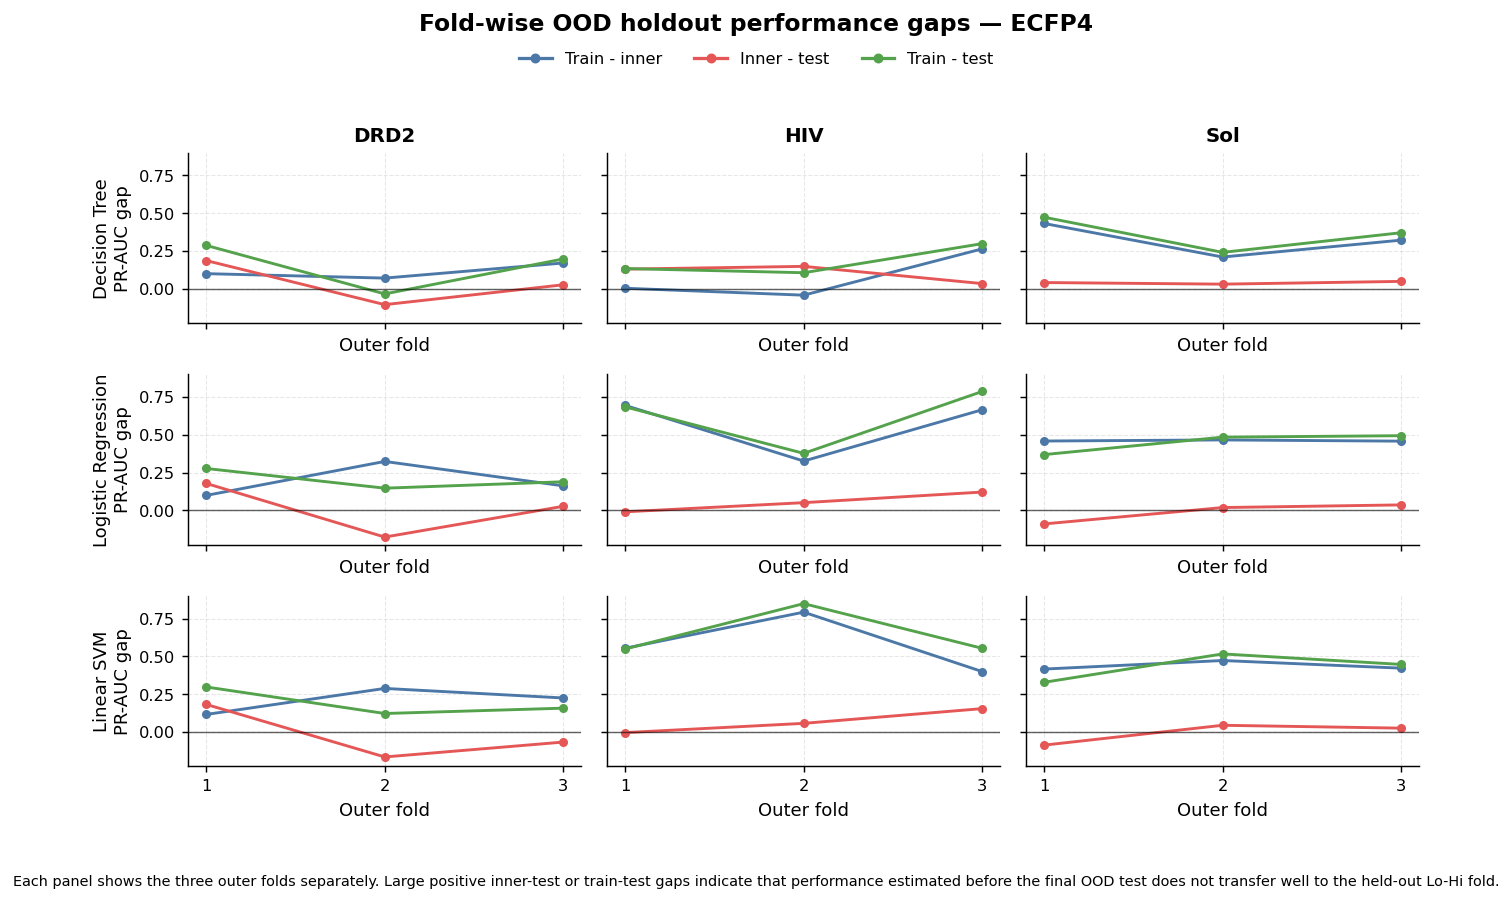

,dataset,model,fold,gap_type,gap,gap_label
0,drd2,DT,1,train_inner_gap,0.100402,Train - inner
1,drd2,DT,2,train_inner_gap,0.070891,Train - inner
2,drd2,DT,3,train_inner_gap,0.170904,Train - inner
3,drd2,LR,1,train_inner_gap,0.098693,Train - inner
4,drd2,LR,2,train_inner_gap,0.323613,Train - inner


In [ ]:
def resolve_metric_column(df: pd.DataFrame, candidates: list[str], label: str) -> str:
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError(
        f"Could not find {label}. Tried {candidates}. Available columns: {df.columns.tolist()}"
    )


def plot_foldwise_ood_performance_gaps(protocol_per_fold: pd.DataFrame) -> pd.DataFrame:
    df = protocol_per_fold.copy()

    df["model"] = df["model"].map(normalize_model)
    df["protocol_norm"] = df["protocol"].map(normalize_protocol)
    df["fingerprint"] = df["fingerprint"].map(normalize_fp)

    df = df[
        (df["dataset"].isin(DATASETS))
        & (df["model"].isin(ALL_MODELS))
        & (df["fingerprint"] == FP)
        & (df["protocol_norm"] == "ood")
    ].copy()

    if df.empty:
        raise ValueError("No OOD holdout ECFP4 rows found in protocol_per_fold.")

    train_col = resolve_metric_column(
        df,
        ["train_score", "train_pr_auc", "train_auc", "train"],
        "train score",
    )

    inner_col = resolve_metric_column(
        df,
        [
            "inner_selection_score",
            "inner_score",
            "inner_pr_auc",
            "val_score",
            "validation_score",
        ],
        "inner validation score",
    )

    test_col = resolve_metric_column(
        df,
        ["test_score", "test_pr_auc", "outer_test_score", "final_test_score", "test"],
        "test score",
    )

    df["train_score_plot"] = pd.to_numeric(df[train_col], errors="coerce")
    df["inner_score_plot"] = pd.to_numeric(df[inner_col], errors="coerce")
    df["test_score_plot"] = pd.to_numeric(df[test_col], errors="coerce")

    df = df.dropna(
        subset=["train_score_plot", "inner_score_plot", "test_score_plot"]
    ).copy()

    df["train_inner_gap"] = df["train_score_plot"] - df["inner_score_plot"]
    df["inner_test_gap"] = df["inner_score_plot"] - df["test_score_plot"]
    df["train_test_gap"] = df["train_score_plot"] - df["test_score_plot"]

    fold_col = "fold"
    df[fold_col] = pd.to_numeric(df[fold_col], errors="coerce").astype(int)

    gap_long = df.melt(
        id_vars=["dataset", "model", "fold"],
        value_vars=["train_inner_gap", "inner_test_gap", "train_test_gap"],
        var_name="gap_type",
        value_name="gap",
    )

    gap_labels = {
        "train_inner_gap": "Train - inner",
        "inner_test_gap": "Inner - test",
        "train_test_gap": "Train - test",
    }

    gap_long["gap_label"] = gap_long["gap_type"].map(gap_labels)

    model_order = [m for m in ALL_MODELS if m in gap_long["model"].unique()]
    dataset_order = [d for d in DATASET_ORDER if d in gap_long["dataset"].unique()]
    gap_order = ["train_inner_gap", "inner_test_gap", "train_test_gap"]

    colors = {
        "train_inner_gap": "#4C78A8",
        "inner_test_gap": "#E45756",
        "train_test_gap": "#54A24B",
    }

    fig, axes = plt.subplots(
        len(model_order),
        len(dataset_order),
        figsize=(10.5, 6.2),
        sharex=True,
        sharey=True,
        squeeze=False,
    )

    for i, model in enumerate(model_order):
        for j, ds in enumerate(dataset_order):
            ax = axes[i, j]

            panel = gap_long[
                (gap_long["dataset"] == ds) & (gap_long["model"] == model)
            ].copy()

            for gap_type in gap_order:
                sub = panel[panel["gap_type"] == gap_type].sort_values("fold")

                if sub.empty:
                    continue

                ax.plot(
                    sub["fold"],
                    sub["gap"],
                    marker="o",
                    linewidth=1.6,
                    markersize=4,
                    color=colors[gap_type],
                    label=gap_labels[gap_type],
                )

            ax.axhline(0, color="black", linewidth=0.8, alpha=0.6)
            ax.set_xticks([1, 2, 3])
            ax.set_xlabel("Outer fold")

            if i == 0:
                ax.set_title(DATASET_LABELS.get(ds, ds), fontweight="bold")

            if j == 0:
                ax.set_ylabel(f"{MODEL_LABELS.get(model, model)}\nPR-AUC gap")

            ax.grid(ls="--", alpha=0.30)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

    handles = [
        Line2D(
            [0],
            [0],
            color=colors[g],
            marker="o",
            linewidth=1.8,
            markersize=4.5,
            label=gap_labels[g],
        )
        for g in gap_order
    ]

    fig.legend(
        handles=handles,
        loc="upper center",
        ncol=3,
        frameon=False,
        bbox_to_anchor=(0.5, 1.015),
    )

    fig.suptitle(
        "Fold-wise OOD holdout performance gaps — ECFP4",
        fontweight="bold",
        fontsize=13,
        y=1.045,
    )

    fig.text(
        0.5,
        -0.025,
        "Each panel shows the three outer folds separately. Large positive inner-test or train-test gaps indicate that performance estimated before the final OOD test does not transfer well to the held-out Lo-Hi fold.",
        ha="center",
        va="top",
        fontsize=8,
    )

    fig.tight_layout(rect=[0, 0.02, 1, 0.98])

    save_fig(fig, "fig3b_foldwise_ood_performance_gaps_ecfp4")

    plt.show()
    plt.close(fig)

    return gap_long


foldwise_ood_gaps = plot_foldwise_ood_performance_gaps(protocol_per_fold)
display(foldwise_ood_gaps.head())

## 4. Task relevance of the shift: List A ∩ List B, Important Random features vs Important OOD features and complexity

List A contains activity-relevant features. List B contains fold-discriminating features. Their overlap is a diagnostic for task-relevant shift: if the same bits predict activity and distinguish folds, then the distribution shift is more likely to affect model selection.

In [12]:
df_overlap = overlap_ab.copy()

if df_overlap.empty:
    raise ValueError("List A vs List B overlap table is empty or missing.")

df_overlap["k"] = pd.to_numeric(df_overlap["k"], errors="coerce")
df_overlap["overlap"] = pd.to_numeric(df_overlap["overlap"], errors="coerce")

display(df_overlap.head())
print("Shape:", df_overlap.shape)
print("Fingerprints:", df_overlap["fingerprint"].unique())
print("Protocols:", df_overlap["activity_protocol"].unique())
print("Models:", df_overlap["model"].unique())
print("Pairs:", df_overlap["pair"].unique())
print("k values:", sorted(df_overlap["k"].dropna().astype(int).unique()))

,dataset,pair,outer_fold,fingerprint,model,activity_protocol,k,effective_k,n_features,n_activity_features,n_shift_features,overlap,n_overlap,random_expected_overlap,expected_overlap_count_random,overlap_enrichment,hypergeom_p_value,overlap_features
0,drd2,F1_vs_F2,1,ecfp4,DT,ood,10,10,2048,10,10,0.1,1,0.004883,0.048828,20.48,0.047872,[2000]
1,drd2,F1_vs_F2,1,ecfp4,DT,random,10,10,2048,10,10,0.1,1,0.004883,0.048828,20.48,0.047872,[2000]
2,drd2,F1_vs_F2,1,ecfp4,LR,ood,10,10,2048,10,10,0.0,0,0.004883,0.048828,0.00,1.000000,[]
3,drd2,F1_vs_F2,1,ecfp4,LR,random,10,10,2048,10,10,0.0,0,0.004883,0.048828,0.00,1.000000,[]
4,drd2,F1_vs_F2,1,ecfp4,SVM,ood,10,10,2048,10,10,0.0,0,0.004883,0.048828,0.00,1.000000,[]


Shape: (324, 18)
Fingerprints: <StringArray>
['ecfp4']
Length: 1, dtype: str
Protocols: <StringArray>
['ood', 'random']
Length: 2, dtype: str
Models: <StringArray>
['DT', 'LR', 'SVM']
Length: 3, dtype: str
Pairs: <StringArray>
['F1_vs_F2', 'F1_vs_F3', 'F2_vs_F3']
Length: 3, dtype: str
k values: [10, 20, 50, 100, 150, 200]


Saved: /home/f.capria/drug-discovery-lohi/results/results_main_diagnostic_notebook/hi/figures/fig4_listA_listB_raw_overlap_foldwise_ood_ecfp4.pdf
Saved: /home/f.capria/drug-discovery-lohi/results/results_main_diagnostic_notebook/hi/figures/fig4_listA_listB_raw_overlap_foldwise_ood_ecfp4.png


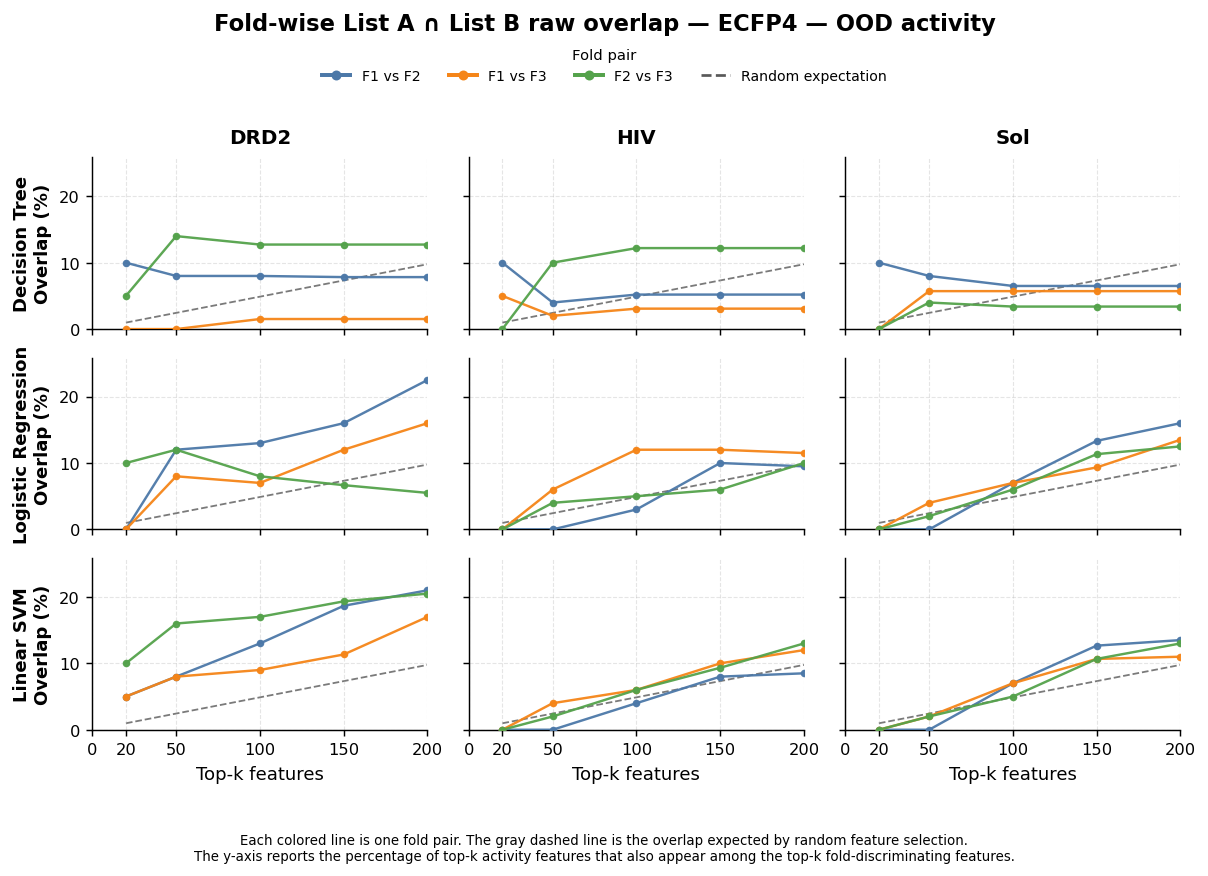

Saved: /home/f.capria/drug-discovery-lohi/results/results_main_diagnostic_notebook/hi/figures/fig4_listA_listB_raw_overlap_foldwise_random_ecfp4.pdf
Saved: /home/f.capria/drug-discovery-lohi/results/results_main_diagnostic_notebook/hi/figures/fig4_listA_listB_raw_overlap_foldwise_random_ecfp4.png


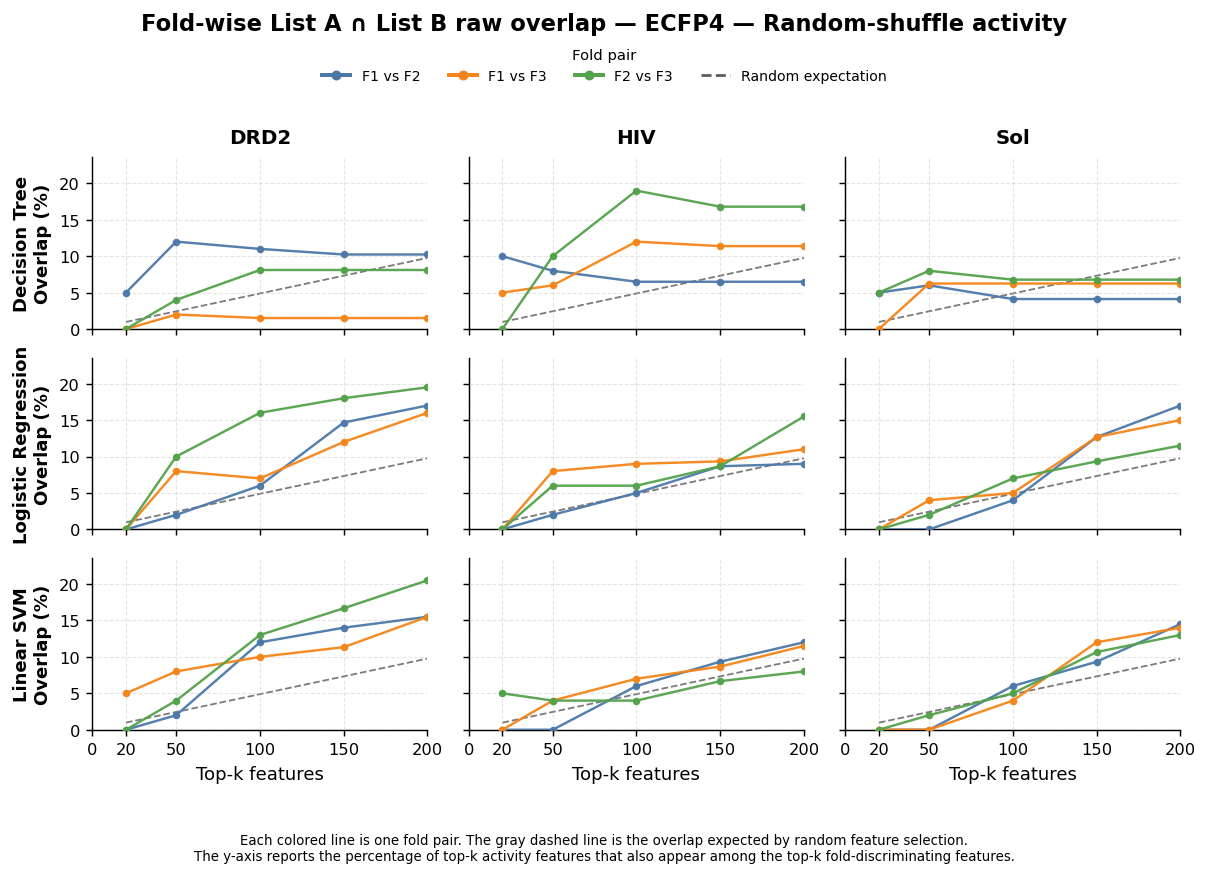

In [13]:
def plot_listA_listB_overlap_ecfp4(
    df_overlap: pd.DataFrame,
    activity_protocol: str = "ood",
    k_values_plot=(20, 50, 100, 150, 200),
) -> pd.DataFrame:

    df = df_overlap.copy()

    df["k"] = pd.to_numeric(df["k"], errors="coerce")
    df["overlap"] = pd.to_numeric(df["overlap"], errors="coerce")
    df = df.dropna(subset=["k", "overlap"]).copy()
    df["k"] = df["k"].astype(int)

    df["fingerprint_norm"] = df["fingerprint"].astype(str).str.lower()
    df = df[
        df["fingerprint_norm"].str.contains("ecfp4")
        | (df["fingerprint_norm"] == "ecfp4")
    ].copy()

    if df.empty:
        raise ValueError("No ECFP4 rows found in df_overlap.")

    df["activity_protocol_norm"] = (
        df["activity_protocol"]
        .astype(str)
        .str.lower()
        .str.replace(" ", "_")
        .str.replace("-", "_")
    )

    activity_protocol = (
        str(activity_protocol).lower().replace(" ", "_").replace("-", "_")
    )

    if activity_protocol in {"ood_holdout", "ood"}:
        activity_protocol = "ood"
        accepted_protocols = {"ood", "ood_holdout"}
    elif activity_protocol in {"random", "random_shuffle"}:
        activity_protocol = "random"
        accepted_protocols = {"random", "random_shuffle"}
    else:
        raise ValueError("activity_protocol must be 'ood' or 'random'.")

    df = df[df["activity_protocol_norm"].isin(accepted_protocols)].copy()

    if df.empty:
        raise ValueError(
            f"No rows available for activity_protocol={activity_protocol!r}."
        )

    df = df[df["k"].isin(k_values_plot)].copy()

    if df.empty:
        raise ValueError(
            f"No rows left after filtering by k_values_plot={k_values_plot}."
        )

    df["model_short"] = df["model"].map(MODEL_SHORT_MAP).fillna(df["model"].astype(str))

    dataset_order = [d for d in DATASET_ORDER if d in df["dataset"].unique()]
    model_order = [m for m in MODEL_ORDER if m in df["model_short"].unique()]

    plot_df = df.groupby(["dataset", "model_short", "pair", "k"], as_index=False).agg(
        overlap=("overlap", "mean")
    )

    plot_df["overlap_percent"] = 100.0 * plot_df["overlap"]

    # ECFP4 has 2048 bits. This is the simple random top-k expectation.
    expectation_df = pd.DataFrame({"k": list(k_values_plot)})
    expectation_df["random_expected_percent"] = 100.0 * expectation_df["k"] / 2048.0

    y_max_data = (
        plot_df["overlap_percent"].replace([np.inf, -np.inf], np.nan).dropna().max()
    )
    y_max_random = expectation_df["random_expected_percent"].max()
    y_upper = min(100.0, max(10.0, 1.15 * max(y_max_data, y_max_random)))

    fig, axes = plt.subplots(
        len(model_order),
        len(dataset_order),
        figsize=(9.4, 5.9),
        sharex=True,
        sharey=True,
        squeeze=False,
    )

    for i, model_short in enumerate(model_order):
        for j, dataset in enumerate(dataset_order):
            ax = axes[i, j]

            ax.plot(
                expectation_df["k"],
                expectation_df["random_expected_percent"],
                color="0.35",
                linestyle="--",
                linewidth=1.0,
                alpha=0.80,
                zorder=1,
            )

            panel_df = plot_df[
                (plot_df["dataset"] == dataset)
                & (plot_df["model_short"] == model_short)
            ].copy()

            for pair in PAIR_ORDER:
                sub = panel_df[panel_df["pair"] == pair].sort_values("k")

                if sub.empty:
                    continue

                ax.plot(
                    sub["k"],
                    sub["overlap_percent"],
                    marker="o",
                    markersize=3.2,
                    lw=1.35,
                    color=PAIR_COLORS.get(pair, "C0"),
                    alpha=0.95,
                    zorder=3,
                )

            ax.set_xlim(0, 200)
            ax.set_xticks([0, 20, 50, 100, 150, 200])
            ax.set_ylim(0, y_upper)
            ax.grid(ls="--", alpha=0.32)

            if i == 0:
                ax.set_title(
                    DATASET_LABELS.get(dataset, dataset.upper()),
                    fontweight="bold",
                    pad=8,
                )

            if j == 0:
                ax.set_ylabel(
                    f"{MODEL_LABELS.get(model_short, model_short)}\nOverlap (%)",
                    fontweight="bold",
                )

            if i == len(model_order) - 1:
                ax.set_xlabel("Top-k features")

            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

    pair_handles = [
        Line2D(
            [0],
            [0],
            color=PAIR_COLORS[pair],
            lw=2.2,
            marker="o",
            markersize=4.5,
            label=PAIR_LABELS[pair],
        )
        for pair in PAIR_ORDER
    ]

    random_handle = Line2D(
        [0],
        [0],
        color="0.35",
        lw=1.5,
        linestyle="--",
        label="Random expectation",
    )

    protocol_label = PROTOCOL_LABELS[activity_protocol]

    fig.legend(
        handles=pair_handles + [random_handle],
        loc="upper center",
        ncol=4,
        frameon=False,
        bbox_to_anchor=(0.5, 1.015),
        title="Fold pair",
        fontsize=7.8,
        title_fontsize=8.2,
    )

    fig.suptitle(
        f"Fold-wise List A ∩ List B raw overlap — ECFP4 — {protocol_label}",
        fontweight="bold",
        fontsize=12.5,
        y=1.045,
    )

    fig.text(
        0.5,
        -0.025,
        "Each colored line is one fold pair. The gray dashed line is the overlap expected by random feature selection.\n"
        "The y-axis reports the percentage of top-k activity features that also appear among the top-k fold-discriminating features.",
        ha="center",
        va="top",
        fontsize=7.4,
    )

    fig.tight_layout(rect=[0, 0.015, 1, 0.975])

    filename = f"fig4_listA_listB_raw_overlap_foldwise_{activity_protocol}_ecfp4"
    save_fig(fig, filename)

    plt.show()
    plt.close(fig)

    return plot_df


listA_listB_overlap_ood_ecfp4 = plot_listA_listB_overlap_ecfp4(
    df_overlap,
    activity_protocol="ood",
    k_values_plot=(20, 50, 100, 150, 200),
)

listA_listB_overlap_random_ecfp4 = plot_listA_listB_overlap_ecfp4(
    df_overlap,
    activity_protocol="random",
    k_values_plot=(20, 50, 100, 150, 200),
)

In [14]:
from matplotlib.lines import Line2D


def load_ood_random_feature_overlap() -> pd.DataFrame:
    required = {
        "dataset",
        "model",
        "fingerprint",
        "fold",
        "top_k",
        "overlap_percent",
    }

    # Prefer tree version because DT should use tree_importance in the new notebook.
    preferred_files = [
        PROJECT_ROOT
        / "results"
        / "results_ood_vs_random_shuffle"
        / "hi"
        / "cross_dataset"
        / "cross_dataset_feature_overlap_tree.csv",
        PROJECT_ROOT
        / "results"
        / "results_ood_vs_random_shuffle"
        / "hi"
        / "cross_dataset"
        / "cross_dataset_feature_overlap.csv",
    ]

    for path in preferred_files:
        if path.exists():
            df = pd.read_csv(path, low_memory=False)
            if required.issubset(df.columns):
                print(f"Loaded overlap table from: {path.name}")
                return df.copy()

    # Fallback: search for any CSV with the right shape.
    search_dir = PROJECT_ROOT / "results"

    candidates = []

    for path in search_dir.rglob("*.csv"):
        try:
            df = pd.read_csv(path, nrows=5, low_memory=False)
        except Exception:
            continue

        if required.issubset(df.columns):
            candidates.append(path)

    if not candidates:
        raise ValueError("No OOD-vs-random feature-overlap table found.")

    path = sorted(candidates)[0]
    print(f"Loaded overlap table from: {path.name}")

    return pd.read_csv(path, low_memory=False)


overlap = load_ood_random_feature_overlap()

overlap["top_k"] = pd.to_numeric(overlap["top_k"], errors="coerce")
overlap["overlap_percent"] = pd.to_numeric(overlap["overlap_percent"], errors="coerce")
overlap["fold"] = pd.to_numeric(overlap["fold"], errors="coerce")

display(overlap.head())
print("Shape:", overlap.shape)
print("Fingerprints:", overlap["fingerprint"].unique())
print("Models:", overlap["model"].unique())
print("Folds:", sorted(overlap["fold"].dropna().astype(int).unique()))
print("k values:", sorted(overlap["top_k"].dropna().astype(int).unique()))

Loaded overlap table from: cross_dataset_feature_overlap_tree.csv


,dataset,model,fingerprint,fold,top_k,n_ood_features,n_random_features,effective_k,n_overlap,n_union,overlap_percent,jaccard_percent,expected_overlap_count_random,random_expected_percent,dataset_order,model_order,fingerprint_order,protocol_order
0,drd2,Decision Tree,ECFP4,1,10,10,10,10,6,14,60.0,42.86,0.0488,0.49,0,0,0,99
1,drd2,Decision Tree,ECFP4,1,20,20,20,20,7,33,35.0,21.21,0.1953,0.98,0,0,0,99
2,drd2,Decision Tree,ECFP4,1,50,50,50,50,10,90,20.0,11.11,1.2207,2.44,0,0,0,99
3,drd2,Decision Tree,ECFP4,1,100,100,100,100,24,176,24.0,13.64,4.8828,4.88,0,0,0,99
4,drd2,Decision Tree,ECFP4,1,150,115,127,127,32,210,25.2,15.24,7.1313,5.62,0,0,0,99


Shape: (378, 18)
Fingerprints: <StringArray>
['ECFP4', 'MACCS', 'RDKit desc']
Length: 3, dtype: str
Models: <StringArray>
['Decision Tree', 'Logistic Regression', 'Linear SVM']
Length: 3, dtype: str
Folds: [1, 2, 3]
k values: [10, 20, 50, 100, 150, 200]


Saved: /home/f.capria/drug-discovery-lohi/results/results_main_diagnostic_notebook/hi/figures/fig4b_ood_vs_random_feature_overlap_foldwise_ecfp4.pdf
Saved: /home/f.capria/drug-discovery-lohi/results/results_main_diagnostic_notebook/hi/figures/fig4b_ood_vs_random_feature_overlap_foldwise_ecfp4.png


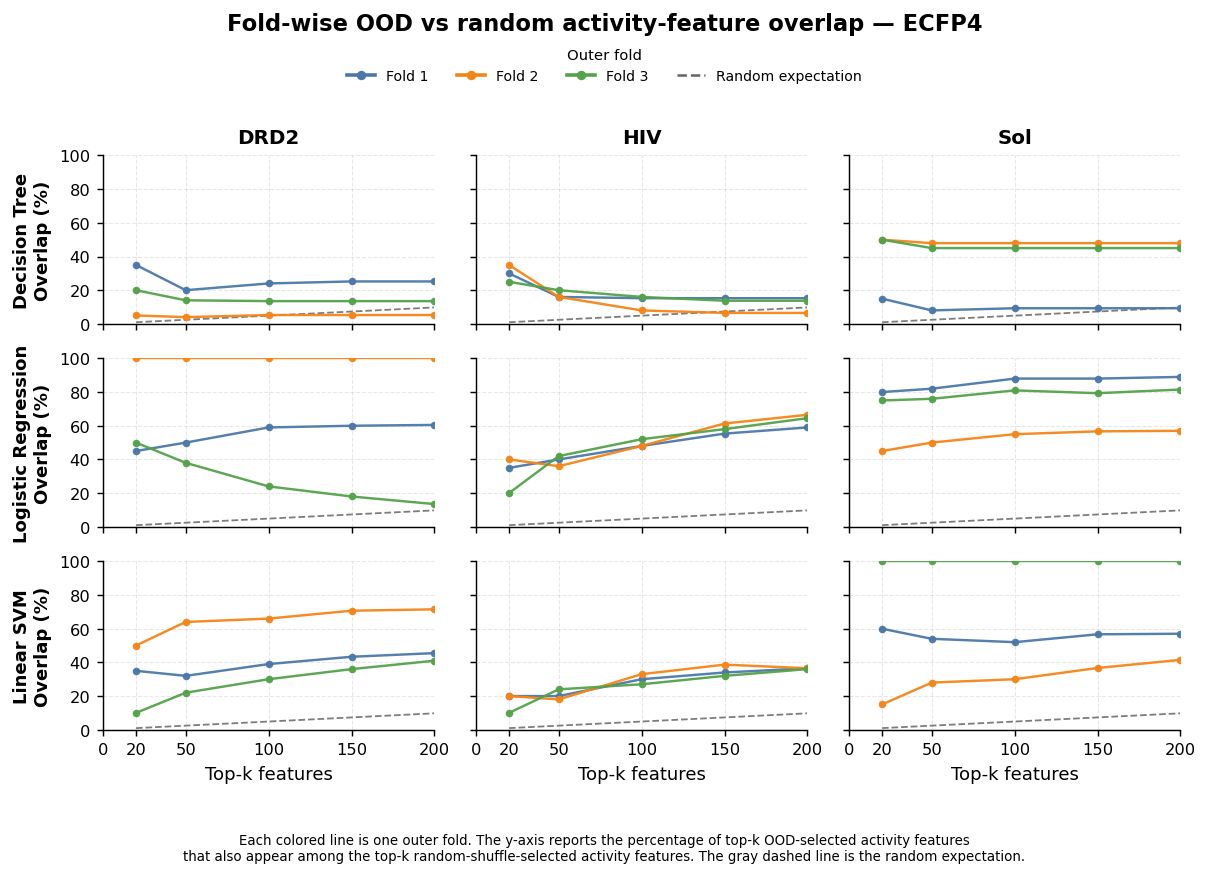

In [15]:
def plot_ood_random_feature_overlap_ecfp4(
    overlap: pd.DataFrame,
    k_values_plot=(20, 50, 100, 150, 200),
) -> pd.DataFrame:

    if overlap.empty:
        print("No overlap data available.")
        return pd.DataFrame()

    df = overlap.copy()

    df["top_k"] = pd.to_numeric(df["top_k"], errors="coerce")
    df["overlap_percent"] = pd.to_numeric(df["overlap_percent"], errors="coerce")
    df["fold"] = pd.to_numeric(df["fold"], errors="coerce")

    df = df.dropna(subset=["top_k", "overlap_percent", "fold"]).copy()

    df["top_k"] = df["top_k"].astype(int)
    df["fold"] = df["fold"].astype(int)

    df["fingerprint_norm"] = df["fingerprint"].astype(str).str.lower()
    df = df[
        df["fingerprint_norm"].str.contains("ecfp4")
        | (df["fingerprint_norm"] == "ecfp4")
    ].copy()

    if df.empty:
        raise ValueError("No ECFP4 rows found in overlap table.")

    df = df[df["top_k"].isin(k_values_plot)].copy()

    if df.empty:
        raise ValueError(
            f"No rows left after filtering by k_values_plot={k_values_plot}."
        )

    model_short_map = {
        "Decision Tree": "DT",
        "Logistic Regression": "LR",
        "Linear SVM": "SVM",
        "DT": "DT",
        "LR": "LR",
        "SVM": "SVM",
        "decision_tree": "DT",
        "lr": "LR",
        "svm": "SVM",
        "svm_linear": "SVM",
    }

    df["model_short"] = df["model"].map(model_short_map).fillna(df["model"].astype(str))

    model_order = [m for m in ["DT", "LR", "SVM"] if m in df["model_short"].unique()]
    dataset_order = [d for d in DATASET_ORDER if d in df["dataset"].unique()]

    model_labels = {
        "DT": "Decision Tree",
        "LR": "Logistic Regression",
        "SVM": "Linear SVM",
    }

    fold_order = [1, 2, 3]

    fold_labels = {
        1: "Fold 1",
        2: "Fold 2",
        3: "Fold 3",
    }

    fold_colors = {
        1: "#4C78A8",
        2: "#F58518",
        3: "#54A24B",
    }

    plot_df = df.groupby(
        ["dataset", "model_short", "fold", "top_k"], as_index=False
    ).agg(overlap_percent=("overlap_percent", "mean"))

    # Simple random top-k expectation for ECFP4.
    expectation_df = pd.DataFrame({"top_k": list(k_values_plot)})
    expectation_df["random_expected_percent"] = 100.0 * expectation_df["top_k"] / 2048.0

    y_max_data = (
        plot_df["overlap_percent"].replace([np.inf, -np.inf], np.nan).dropna().max()
    )
    y_max_random = expectation_df["random_expected_percent"].max()

    y_upper = min(
        100.0,
        max(20.0, 1.12 * max(y_max_data, y_max_random)),
    )

    fig, axes = plt.subplots(
        len(model_order),
        len(dataset_order),
        figsize=(9.4, 5.9),
        sharex=True,
        sharey=True,
        squeeze=False,
    )

    for i, model_short in enumerate(model_order):
        for j, dataset in enumerate(dataset_order):
            ax = axes[i, j]

            ax.plot(
                expectation_df["top_k"],
                expectation_df["random_expected_percent"],
                color="0.40",
                linestyle="--",
                linewidth=1.0,
                alpha=0.85,
                zorder=1,
            )

            panel_df = plot_df[
                (plot_df["dataset"] == dataset)
                & (plot_df["model_short"] == model_short)
            ].copy()

            for fold in fold_order:
                sub = panel_df[panel_df["fold"] == fold].sort_values("top_k")

                if sub.empty:
                    continue

                ax.plot(
                    sub["top_k"],
                    sub["overlap_percent"],
                    marker="o",
                    markersize=3.2,
                    lw=1.35,
                    color=fold_colors.get(fold, "C0"),
                    alpha=0.95,
                    zorder=3,
                )

            ax.set_xlim(0, 200)
            ax.set_xticks([0, 20, 50, 100, 150, 200])
            ax.set_ylim(0, y_upper)
            ax.grid(ls="--", alpha=0.30)

            if i == 0:
                ax.set_title(
                    DATASET_LABELS.get(dataset, dataset.upper()),
                    fontweight="bold",
                    pad=7,
                )

            if j == 0:
                ax.set_ylabel(
                    f"{model_labels.get(model_short, model_short)}\nOverlap (%)",
                    fontweight="bold",
                )

            if i == len(model_order) - 1:
                ax.set_xlabel("Top-k features")

            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

    fold_handles = [
        Line2D(
            [0],
            [0],
            color=fold_colors[fold],
            lw=2.0,
            marker="o",
            markersize=4.2,
            label=fold_labels[fold],
        )
        for fold in fold_order
    ]

    random_handle = Line2D(
        [0],
        [0],
        color="0.40",
        lw=1.4,
        linestyle="--",
        label="Random expectation",
    )

    fig.legend(
        handles=fold_handles + [random_handle],
        loc="upper center",
        ncol=4,
        frameon=False,
        bbox_to_anchor=(0.5, 1.015),
        title="Outer fold",
        fontsize=7.8,
        title_fontsize=8.2,
    )

    fig.suptitle(
        "Fold-wise OOD vs random activity-feature overlap — ECFP4",
        fontweight="bold",
        fontsize=12.5,
        y=1.045,
    )

    fig.text(
        0.5,
        -0.025,
        "Each colored line is one outer fold. The y-axis reports the percentage of top-k OOD-selected activity features\n"
        "that also appear among the top-k random-shuffle-selected activity features. The gray dashed line is the random expectation.",
        ha="center",
        va="top",
        fontsize=7.4,
    )

    fig.tight_layout(rect=[0, 0.015, 1, 0.975])

    save_fig(fig, "fig4b_ood_vs_random_feature_overlap_foldwise_ecfp4")

    plt.show()
    plt.close(fig)

    return plot_df


figure4b_ood_vs_random_feature_overlap_ecfp4 = plot_ood_random_feature_overlap_ecfp4(
    overlap,
    k_values_plot=(20, 50, 100, 150, 200),
)

In [16]:
def clean_model_name(x):
    x = str(x)
    if x in ["Decision Tree", "DT", "decision_tree"]:
        return "DT"
    if x in ["Logistic Regression", "LR", "lr"]:
        return "LR"
    if x in ["Linear SVM", "SVM", "svm", "svm_linear"]:
        return "SVM"
    return x


def clean_protocol_name(x):
    x = str(x).lower().replace(" ", "_").replace("-", "_")
    if x in ["ood", "ood_holdout"]:
        return "OOD holdout"
    if x in ["random", "random_shuffle"]:
        return "Random shuffle"
    return x


def clean_fingerprint_name(x):
    x = str(x).lower()
    if "ecfp4" in x:
        return "ECFP4"
    if "maccs" in x:
        return "MACCS"
    if "rdkit" in x and "topo" in x:
        return "RDKit topo"
    if "rdkit" in x:
        return "RDKit desc"
    return str(x)


def find_l1_column(df):
    for c in [
        "l1_norm",
        "coef_l1_norm",
        "weight_l1_norm",
        "abs_coef_sum",
        "coef_abs_sum",
        "weight_abs_sum",
        "l1_abs_sum",
    ]:
        if c in df.columns:
            return c
    raise ValueError("No L1 norm column found for LR/SVM.")


def build_complexity_summary(complexity_all):
    df = complexity_all.copy()

    df["model_clean"] = df["model"].apply(clean_model_name)
    df["protocol_clean"] = df["protocol"].apply(clean_protocol_name)
    df["fingerprint_clean"] = df["fingerprint"].apply(clean_fingerprint_name)

    l1_col = find_l1_column(df)

    rows = []

    for _, row in df.iterrows():
        model = row["model_clean"]

        if model == "DT":
            metric_col = "n_nodes"
            metric_label = "Number of tree nodes"
        elif model == "LR":
            metric_col = l1_col
            metric_label = "L1 norm of coefficients"
        elif model == "SVM":
            metric_col = l1_col
            metric_label = "L1 norm of weights"
        else:
            continue

        if metric_col not in df.columns:
            continue

        value = pd.to_numeric(pd.Series([row[metric_col]]), errors="coerce").iloc[0]

        if pd.isna(value) or value <= 0:
            continue

        rows.append(
            {
                "dataset": row["dataset"],
                "dataset_label": row.get(
                    "dataset_label", DATASET_LABELS.get(row["dataset"], row["dataset"])
                ),
                "model": model,
                "fingerprint": row["fingerprint_clean"],
                "protocol": row["protocol_clean"],
                "fold": row["fold"],
                "complexity_metric": metric_col,
                "complexity_description": metric_label,
                "complexity_value": float(value),
            }
        )

    out = pd.DataFrame(rows)

    out = out[out["protocol"].isin(["OOD holdout", "Random shuffle"])].copy()

    summary = out.groupby(
        [
            "dataset",
            "dataset_label",
            "model",
            "fingerprint",
            "protocol",
            "complexity_metric",
            "complexity_description",
        ],
        as_index=False,
    ).agg(
        mean_complexity=("complexity_value", "mean"),
        std_complexity=("complexity_value", "std"),
        n_folds=("complexity_value", "count"),
    )

    summary["mean_complexity"] = summary["mean_complexity"].round(4)
    summary["std_complexity"] = summary["std_complexity"].round(4)

    summary.to_csv(TAB_DIR / "tab_model_complexity_by_protocol.csv", index=False)

    print("Models:", summary["model"].unique())
    print("Fingerprints:", summary["fingerprint"].unique())
    print("Protocols:", summary["protocol"].unique())

    return summary


tab_model_complexity = build_complexity_summary(complexity_all)
display(tab_model_complexity)

Models: <StringArray>
['DT', 'LR', 'SVM']
Length: 3, dtype: str
Fingerprints: <StringArray>
['ECFP4']
Length: 1, dtype: str
Protocols: <StringArray>
['OOD holdout', 'Random shuffle']
Length: 2, dtype: str


,dataset,dataset_label,model,fingerprint,protocol,complexity_metric,complexity_description,mean_complexity,std_complexity,n_folds
0,drd2,DRD2,DT,ECFP4,OOD holdout,n_nodes,Number of tree nodes,131.0000,124.7718,3
1,drd2,DRD2,DT,ECFP4,Random shuffle,n_nodes,Number of tree nodes,178.3333,79.1033,3
2,drd2,DRD2,LR,ECFP4,OOD holdout,l1_norm,L1 norm of coefficients,163.1338,230.3761,3
3,drd2,DRD2,LR,ECFP4,Random shuffle,l1_norm,L1 norm of coefficients,335.5240,137.8173,3
4,drd2,DRD2,SVM,ECFP4,OOD holdout,l1_norm,L1 norm of weights,91.3168,106.0132,3
5,drd2,DRD2,SVM,ECFP4,Random shuffle,l1_norm,L1 norm of weights,196.3390,37.7398,3
6,hiv,HIV,DT,ECFP4,OOD holdout,n_nodes,Number of tree nodes,67.6667,45.0037,3
7,hiv,HIV,DT,ECFP4,Random shuffle,n_nodes,Number of tree nodes,233.6667,96.0278,3
8,hiv,HIV,LR,ECFP4,OOD holdout,l1_norm,L1 norm of coefficients,391.5793,25.7623,3
9,hiv,HIV,LR,ECFP4,Random shuffle,l1_norm,L1 norm of coefficients,232.4847,16.0497,3


Saved: /home/f.capria/drug-discovery-lohi/results/results_main_diagnostic_notebook/hi/figures/fig_model_complexity_dt.pdf
Saved: /home/f.capria/drug-discovery-lohi/results/results_main_diagnostic_notebook/hi/figures/fig_model_complexity_dt.png


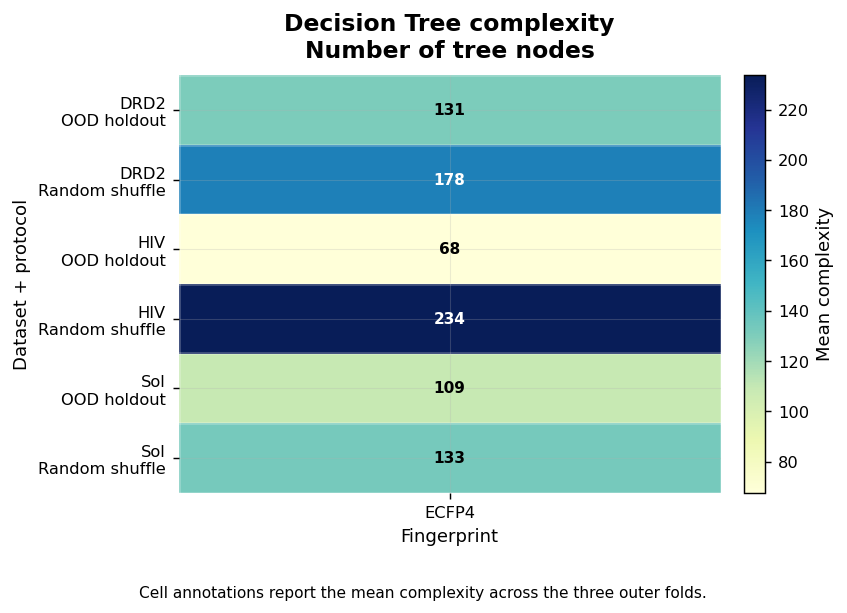

Saved: /home/f.capria/drug-discovery-lohi/results/results_main_diagnostic_notebook/hi/figures/fig_model_complexity_lr.pdf
Saved: /home/f.capria/drug-discovery-lohi/results/results_main_diagnostic_notebook/hi/figures/fig_model_complexity_lr.png


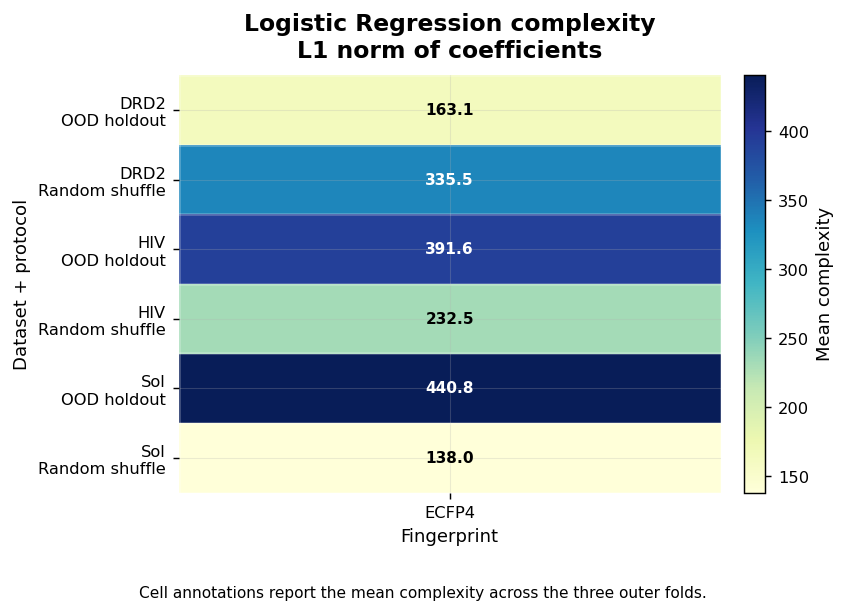

Saved: /home/f.capria/drug-discovery-lohi/results/results_main_diagnostic_notebook/hi/figures/fig_model_complexity_svm.pdf
Saved: /home/f.capria/drug-discovery-lohi/results/results_main_diagnostic_notebook/hi/figures/fig_model_complexity_svm.png


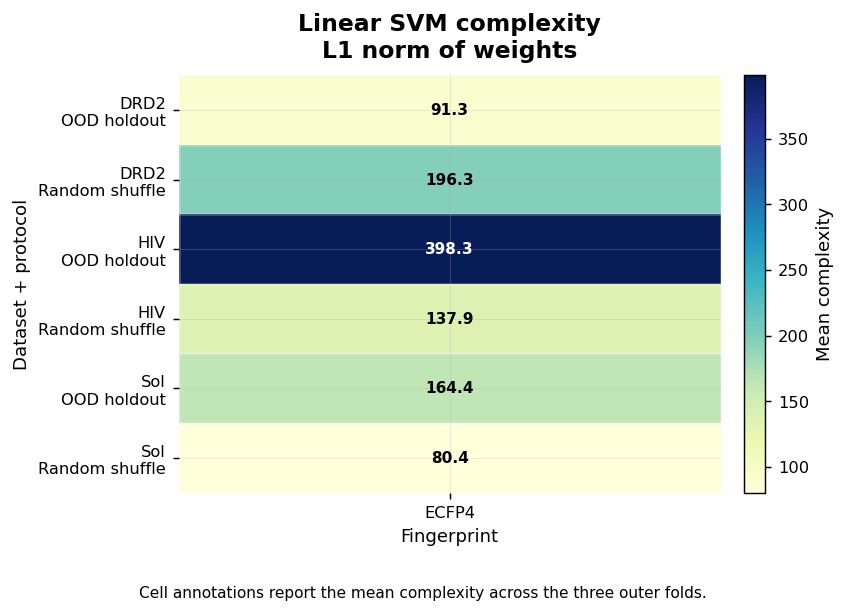

In [17]:
import matplotlib as mpl


def plot_complexity_one_model(tab, model):
    df = tab[tab["model"] == model].copy()

    if df.empty:
        print(f"No rows for model={model}")
        return pd.DataFrame()

    dataset_order = [
        DATASET_LABELS[d]
        for d in DATASET_ORDER
        if DATASET_LABELS[d] in df["dataset_label"].unique()
    ]

    protocol_order = ["OOD holdout", "Random shuffle"]
    fp_order = ["ECFP4", "MACCS", "RDKit desc", "RDKit topo"]
    fp_order = [fp for fp in fp_order if fp in df["fingerprint"].unique()]

    df["row"] = df["dataset_label"].astype(str) + "\n" + df["protocol"].astype(str)

    row_order = []
    for ds in dataset_order:
        for protocol in protocol_order:
            r = f"{ds}\n{protocol}"
            if r in df["row"].unique():
                row_order.append(r)

    heatmap = df.pivot_table(
        index="row",
        columns="fingerprint",
        values="mean_complexity",
        aggfunc="mean",
    ).reindex(index=row_order, columns=fp_order)

    values = heatmap.values.astype(float)

    if np.all(~np.isfinite(values)):
        print(f"No finite values for model={model}")
        print("Available rows:")
        display(df.head())
        print("Heatmap:")
        display(heatmap)
        return pd.DataFrame()

    vmin = np.nanmin(values)
    vmax = np.nanmax(values)

    fig, ax = plt.subplots(figsize=(6.6, 4.4))

    cmap = mpl.colormaps["YlGnBu"].copy()
    cmap.set_bad(color="lightgray")

    im = ax.imshow(
        np.ma.masked_invalid(values),
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        aspect="auto",
    )

    ax.set_xticks(np.arange(len(heatmap.columns)))
    ax.set_xticklabels(heatmap.columns, fontsize=9)

    ax.set_yticks(np.arange(len(heatmap.index)))
    ax.set_yticklabels(heatmap.index, fontsize=9)

    model_titles = {
        "DT": "Decision Tree",
        "LR": "Logistic Regression",
        "SVM": "Linear SVM",
    }

    metric_label = df["complexity_description"].iloc[0]

    ax.set_title(
        f"{model_titles.get(model, model)} complexity\n{metric_label}",
        fontsize=13,
        fontweight="bold",
        pad=10,
    )

    ax.set_xlabel("Fingerprint")
    ax.set_ylabel("Dataset + protocol")

    ax.set_xticks(np.arange(-0.5, len(heatmap.columns), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(heatmap.index), 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.5)
    ax.tick_params(which="minor", bottom=False, left=False)

    midpoint = (vmin + vmax) / 2

    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            val = values[i, j]

            if pd.isna(val):
                label = "NA"
                color = "black"
            else:
                if model == "DT":
                    label = f"{val:.0f}"
                elif val >= 10:
                    label = f"{val:.1f}"
                else:
                    label = f"{val:.2f}"

                color = "white" if val > midpoint else "black"

            ax.text(
                j,
                i,
                label,
                ha="center",
                va="center",
                fontsize=8.5,
                fontweight="bold",
                color=color,
            )

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Mean complexity")

    ax.spines[["top", "right", "bottom", "left"]].set_visible(False)

    fig.text(
        0.5,
        -0.035,
        "Cell annotations report the mean complexity across the three outer folds.",
        ha="center",
        va="top",
        fontsize=8.5,
    )

    fig.tight_layout()

    save_fig(fig, f"fig_model_complexity_{model.lower()}")

    plt.show()
    plt.close(fig)

    return df


complexity_dt = plot_complexity_one_model(tab_model_complexity, "DT")
complexity_lr = plot_complexity_one_model(tab_model_complexity, "LR")
complexity_svm = plot_complexity_one_model(tab_model_complexity, "SVM")

## 6. Final diagnosis table

The final table is intentionally compact. It does not hard-route datasets in advance. It summarizes which diagnostic pattern each dataset follows.

The final flags are intentionally descriptive. For conditional-instability, both absolute and relative PR-AUC gaps are reported, because absolute PR-AUC gaps are not directly comparable across datasets with very different base rates.


In [18]:
def safe_mean(df: pd.DataFrame, col: str) -> float:
    if df is None or df.empty or col not in df.columns:
        return np.nan
    return float(pd.to_numeric(df[col], errors="coerce").mean())


def safe_sum(df: pd.DataFrame, col: str) -> float:
    if df is None or df.empty or col not in df.columns:
        return np.nan
    return float(pd.to_numeric(df[col], errors="coerce").sum())


def build_class_balance_summary_if_needed() -> pd.DataFrame:
    if "class_balance_summary" in globals():
        out = class_balance_summary.copy()

        if "range_positive_rate" not in out.columns:
            if "positive_rate_range" in out.columns:
                out["range_positive_rate"] = out["positive_rate_range"]
            elif {"max_positive_rate", "min_positive_rate"}.issubset(out.columns):
                out["range_positive_rate"] = (
                    out["max_positive_rate"] - out["min_positive_rate"]
                )

        return out

    if "class_balance" not in globals():
        raise ValueError("class_balance or class_balance_summary is missing.")

    cb = class_balance.copy()

    if "positive_rate" not in cb.columns:
        raise ValueError("class_balance must contain positive_rate.")

    out = cb.groupby(["dataset"], as_index=False).agg(
        mean_positive_rate=("positive_rate", "mean"),
        min_positive_rate=("positive_rate", "min"),
        max_positive_rate=("positive_rate", "max"),
    )

    out["range_positive_rate"] = out["max_positive_rate"] - out["min_positive_rate"]
    out["dataset_label"] = out["dataset"].map(DATASET_LABELS)

    return out


def build_protocol_perf_if_needed() -> pd.DataFrame:
    if "protocol_perf" in globals():
        return protocol_perf.copy()

    if "summary" not in globals():
        raise ValueError("summary or protocol_perf is missing.")

    df = summary.copy()

    needed = ["dataset", "train_mean", "inner_mean", "test_mean"]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(f"summary is missing columns: {missing}")

    eps = 1e-8

    df["gap_train_val"] = df["train_mean"] - df["inner_mean"]
    df["gap_val_test"] = df["inner_mean"] - df["test_mean"]
    df["gap_train_test"] = df["train_mean"] - df["test_mean"]

    df["gap_train_val_relative"] = df["gap_train_val"] / (df["train_mean"].abs() + eps)
    df["gap_val_test_relative"] = df["gap_val_test"] / (df["inner_mean"].abs() + eps)
    df["gap_train_test_relative"] = df["gap_train_test"] / (
        df["train_mean"].abs() + eps
    )

    out = df.groupby("dataset", as_index=False).agg(
        gap_train_val=("gap_train_val", "mean"),
        gap_val_test=("gap_val_test", "mean"),
        gap_train_test=("gap_train_test", "mean"),
        gap_train_val_relative=("gap_train_val_relative", "mean"),
        gap_val_test_relative=("gap_val_test_relative", "mean"),
        gap_train_test_relative=("gap_train_test_relative", "mean"),
    )

    return out


def build_final_diagnosis() -> pd.DataFrame:
    cb_summary = build_class_balance_summary_if_needed()
    perf_summary = build_protocol_perf_if_needed()

    model_set = [
        m for m in ["DT", "LR", "SVM"] if m in tab2_ranking_stability["model"].unique()
    ]

    rows = []

    for ds in DATASETS:
        cb = cb_summary[cb_summary["dataset"] == ds]

        rank = tab2_ranking_stability[
            (tab2_ranking_stability["dataset"] == ds)
            & (tab2_ranking_stability["model"].isin(model_set))
        ]

        tan = tanimoto_summary[
            (tanimoto_summary["dataset"] == ds)
            & (tanimoto_summary["model"].isin(model_set))
            & (tanimoto_summary["bit_source"] == "activity_ood")
        ].copy()

        if "high_coverage_recommended_for_main_plot" in tan.columns:
            tan = tan[tan["high_coverage_recommended_for_main_plot"].astype(bool)]

        perf = perf_summary[perf_summary["dataset"] == ds]

        mean_positive_rate = safe_mean(cb, "mean_positive_rate")
        prior_range = safe_mean(cb, "range_positive_rate")
        if pd.isna(prior_range):
            prior_range = safe_mean(cb, "positive_rate_range")

        mean_rbo = safe_mean(rank, "mean_rbo")
        mean_tau = safe_mean(rank, "mean_tau")

        activity_z = safe_mean(tan, "delta_minus_random_bits_pairwise_z_main")
        activity_delta = safe_mean(tan, "delta_minus_random_bits_pairwise_main")

        train_val_gap = safe_mean(perf, "gap_train_val")
        val_test_gap = safe_mean(perf, "gap_val_test")
        train_test_gap = safe_mean(perf, "gap_train_test")

        train_val_gap_relative = safe_mean(perf, "gap_train_val_relative")
        val_test_gap_relative = safe_mean(perf, "gap_val_test_relative")
        train_test_gap_relative = safe_mean(perf, "gap_train_test_relative")

        absolute_gap_flag = (
            (train_test_gap >= 0.15) or (val_test_gap >= 0.10)
            if pd.notna(train_test_gap) and pd.notna(val_test_gap)
            else np.nan
        )

        relative_gap_flag = (
            (train_test_gap_relative >= 0.30) or (val_test_gap_relative >= 0.30)
            if pd.notna(train_test_gap_relative) and pd.notna(val_test_gap_relative)
            else np.nan
        )

        if isinstance(relative_gap_flag, (bool, np.bool_)):
            conditional_flag = bool(relative_gap_flag)
        else:
            conditional_flag = np.nan

        rows.append(
            {
                "dataset": ds,
                "dataset_label": DATASET_LABELS.get(ds, ds),
                # Class composition / prior shift
                "mean_positive_rate": mean_positive_rate,
                "prior_shift_range": prior_range,
                # Activity-rule stability
                "mean_RBO_all_models": mean_rbo,
                "mean_Kendall_tau_all_models": mean_tau,
                # Activity-subspace fold distance
                "activity_vs_random_delta_main": activity_delta,
                "activity_vs_random_z_main": activity_z,
                "n_high_coverage_activity_rows": int(len(tan)),
                # Performance gaps
                "mean_train_val_gap": train_val_gap,
                "mean_val_test_gap": val_test_gap,
                "mean_train_test_gap": train_test_gap,
                "mean_train_val_gap_relative": train_val_gap_relative,
                "mean_val_test_gap_relative": val_test_gap_relative,
                "mean_train_test_gap_relative": train_test_gap_relative,
                # Indicative flags, not formal tests
                "extreme_class_imbalance_indicative": (
                    mean_positive_rate < 0.10
                    if pd.notna(mean_positive_rate)
                    else np.nan
                ),
                "prior_shift_indicative": (
                    prior_range >= 0.10 if pd.notna(prior_range) else np.nan
                ),
                "stable_activity_rule_indicative": (
                    mean_rbo >= 0.60 if pd.notna(mean_rbo) else np.nan
                ),
                "activity_shift_below_random_indicative": (
                    activity_z <= -1.0 if pd.notna(activity_z) else np.nan
                ),
                "absolute_gap_instability_indicative": absolute_gap_flag,
                "relative_gap_instability_indicative": relative_gap_flag,
                "conditional_instability_indicative": conditional_flag,
            }
        )

    out = pd.DataFrame(rows)

    numeric_cols = out.select_dtypes(include="number").columns
    out[numeric_cols] = out[numeric_cols].round(4)

    out.to_csv(TAB_DIR / "tab6_final_diagnosis.csv", index=False)

    return out


tab6_final_diagnosis = build_final_diagnosis()
display(tab6_final_diagnosis)

,dataset,dataset_label,mean_positive_rate,prior_shift_range,mean_RBO_all_models,mean_Kendall_tau_all_models,activity_vs_random_delta_main,activity_vs_random_z_main,n_high_coverage_activity_rows,mean_train_val_gap,...,mean_train_val_gap_relative,mean_val_test_gap_relative,mean_train_test_gap_relative,extreme_class_imbalance_indicative,prior_shift_indicative,stable_activity_rule_indicative,activity_shift_below_random_indicative,absolute_gap_instability_indicative,relative_gap_instability_indicative,conditional_instability_indicative
0,drd2,DRD2,0.6766,0.1437,0.0820,-0.4051,-0.0180,-0.1914,25,0.1123,...,0.1196,0.0950,0.2095,False,True,False,False,True,False,False
1,hiv,HIV,0.0399,0.0345,0.1049,-0.4742,0.0157,0.4165,17,0.3037,...,0.4896,0.6934,0.8787,True,False,False,False,True,True,True
2,sol,Sol,0.2154,0.0194,0.1186,-0.3867,0.0138,0.1516,26,0.3461,...,0.4097,0.0888,0.4653,False,False,False,False,True,True,True
